In [1]:
#imports
# Using /home2/odiaz/conda/envs/vina environment
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
import os
from rdkit.ML.Scoring.Scoring import CalcBEDROC

In [2]:
# Functions to calculate and plot ROC curves and AUC values
# Code from bootstrap_tldr.py (DUDE-Z) adapted for reading pandas dataframe inputs and use within jupyter notebook
def compute_roc(actives, decoys, nbins=10000,ligname_col="LigName", score_col="docking_score"):
    """Sort scores and iterate through them, counting how many actives have been found at each point to compute ROC curve points.
    Specify the ligand name column and the score column in the CSV file (e.g. 'LigName' and 'docking_score' for ringtail, 's_lp_Variant' and 'r_i_docking_score' for Glide)"""
    num_data = len(actives) + len(decoys)
    num_actives = len(actives)
    num_decoys = len(decoys)
    binsize = int(num_data/nbins) + 1
    
    scores = pd.concat([actives, decoys], ignore_index=True).sort_values(score_col)
    found_active = 0
    results = []
    for i in range(num_data):
        if i % binsize == 0:
            results.append([i-found_active, found_active])
        if scores.iloc[i][ligname_col] in actives[ligname_col].values:
            found_active += 1
    results.append([num_data - found_active, found_active])
    results.append([num_decoys, num_actives])

    points = []
    for x in results:
        fpr = x[0]*100.0/num_decoys
        tpr = x[1]*100.0/num_actives
        points.append((fpr, tpr))
    return points

def interpolate_curve(points):
    i = 0
    while i < len(points) and points[i][0] == 0:
        i += 1
    slope = (points[i][1] - points[i-1][1])/(points[i][0] - points[i-1][0])
    intercept = points[i][1] - slope * points[i][0]
    point_one =  [0.100001, (slope * 0.100001 + intercept)]
    npoints = [x for x in points]
    npoints.insert(i, point_one)
    return npoints

def AUC(points):
    """Calulate the area under the curve using trapezoid rule."""
    auc = 0.0
    for point2, point1 in zip(points[1:], points[:-1]):
        #print(point2, point1)
        base = (point2[0] - point1[0]) / 100.0
        height = ( (point2[1] - point1[1])/2.0 + point1[1] ) / 100.0
        auc += (base*height)
    return auc

def logAUC(points):
    # constants
	## if you modify also change in plots.py        
	LOGAUC_MAX = 1.0   ## this should not change
	LOGAUC_MIN = 0.001 ## this you may want to change if you database is large and you have strong early enrichment. 
	RANDOM_LOGAUC = (LOGAUC_MAX-LOGAUC_MIN)/np.log(10)/np.log10(LOGAUC_MAX/LOGAUC_MIN)


	"""Compute semilog x AUC minus the perfectly random semilog AUC."""
	# assumes we have previously interpolated to get y-value at x = 0.1% 
	# generate new points array clamped between 0.1% and 100%

	npoints = []
	for x in points:
		if (x[0] >= LOGAUC_MIN*100) and (x[0] <= LOGAUC_MAX*100):
			npoints.append( [x[0]/100 , x[1]/100] )

	area = 0.0
	for point2, point1 in zip(npoints[1:], npoints[:-1]):
		if point2[0] - point1[0] < 0.000001:
			continue

		# segment area computed as integral of log transformed equation
		dx = point2[0]-point1[0]
		dy = point2[1]-point1[1]
		intercept = point2[1] - (dy)/(dx) * point2[0]
		area += dy/np.log(10) + intercept*(np.log10(point2[0])-np.log10(point1[0]))

	# print("logAUC", area, area/np.log10(LOGAUC_MAX/LOGAUC_MIN) - RANDOM_LOGAUC)
	return area/np.log10(LOGAUC_MAX/LOGAUC_MIN) - RANDOM_LOGAUC

def plot_roc(actives, decoys,nbins=10000,ligname_col="LigName", score_col="docking_score"):
    points = compute_roc(actives, decoys, nbins=nbins, ligname_col=ligname_col, score_col=score_col)
    points = interpolate_curve(points)
    auc = AUC(points)*100
    logauc = logAUC(points)*100

    fig = plt.figure(figsize=(12,6))
    fig.subplots_adjust(hspace=0.4, wspace=0.4)
    sns.set_style("ticks")
    sns.set_context("notebook",font_scale=1.25)
    gs = fig.add_gridspec(1,2)
    x = np.arange(0,100,0.1)

    ax = fig.add_subplot(gs[0,0])
    ax.plot(x, x, linestyle="--", color="gray")
    ax.axis([-0.5, 100.5, -0.5, 100.5])
    ax.plot([x[0] for x in points], [x[1] for x in points], label=f"AUC: {auc:.2f}")
    ax.plot([0,100], [0,100], linestyle="--", color="gray")
    ax.set_xlabel("Selected decoys (%)")
    ax.set_ylabel("Selected actives (%)")
    ax.set_title("ROC Curve")
    ax.legend()

    ax = fig.add_subplot(gs[0,1])
    ax.semilogx(x, x, '--', color="gray")
    ax.axis([0.1, 100, 0, 100.5])
    ax.set_xlabel("Selected decoys (%)")
    ax.set_ylabel("Selected actives (%)")
    logx, logy = zip(*points)
    ax.semilogx(logx, logy, linewidth=1.5, label='logAUC: %.2f' % logauc)
    # ax1.semilogx(x, y, linewidth=1)
    ax.set_title("Semi-log ROC Curve")
    ax.legend()
    fig.tight_layout(pad=2.0)

#################################################################################################
def bootstrap_single_keep_ratio(actives, decoys,metrics,nbins=10000,ligname_col="LigName", score_col="docking_score",num_bootstrap_replicate=50):
	"""Perform bootstrap resampling of actives and decoys keeping the same n actives and decoys, compute ROC and AUC for each replicate and calculate the confidence intervals of AUC at 95%.
	Metrics can be AUC of logAUC."""
	lig_scores = actives[score_col].tolist()
	decoy_scores = decoys[score_col].tolist()

	print(f'lig_list:  {len(actives[ligname_col])},   decoy_list:{len(decoys[ligname_col])}')
	print(f'lig_scores:{len(lig_scores)}, decoy_scores:{len(decoy_scores)}')

	fig = plt.figure(figsize=(10, 5))
	fig.subplots_adjust(hspace=0.4, wspace=0.4)
	sns.set_style("whitegrid")
	sns.set_context("notebook", font_scale=1.0)
	ax1 = fig.add_subplot(1, 2, 1)

	x = np.arange(0,100,0.1)
	if metrics == "AUC":
		ax1.plot(x, x, 'k--')
		ax1.axis([-0.25, 100, 0, 100])
		ax1.set_xlabel(" Decoys Found %")
		ax1.set_ylabel(" Ligands Found %")

		list_logauc = []
		for i in tqdm(range(num_bootstrap_replicate), ncols=100):
			bootstrap_lig_indeces   = np.random.randint(0, len(lig_scores),   size=len(lig_scores))
			bootstrap_decoy_indeces = np.random.randint(0, len(decoy_scores), size=len(decoy_scores))
			new_ligs   = pd.DataFrame([actives.iloc[i] for i in bootstrap_lig_indeces])
			new_decoys = pd.DataFrame([decoys.iloc[i] for i in bootstrap_decoy_indeces])

			points = compute_roc(new_ligs, new_decoys,nbins=nbins,ligname_col=ligname_col, score_col=score_col)
			points = interpolate_curve(points)

			auc    = AUC(points)*100
			list_logauc.append(auc)

			if i <= 10:
				x, y = zip(*points)
				ax1.plot(x, y, linewidth=1, label='AUC: %.2f' % auc)
				# ax1.plot(x, y, linewidth=1)
				
	elif metrics == "logAUC":
		ax1.semilogx(x, x, 'k--')
		ax1.axis([0.1, 100, 0, 100])
		ax1.set_xlabel(" Decoys Found %")
		ax1.set_ylabel(" Ligands Found %")

		list_logauc = []
		for i in tqdm(range(num_bootstrap_replicate), ncols=100):
			bootstrap_lig_indeces   = np.random.randint(0, len(lig_scores),   size=len(lig_scores))
			bootstrap_decoy_indeces = np.random.randint(0, len(decoy_scores), size=len(decoy_scores))
			new_ligs   = pd.DataFrame([actives.iloc[i] for i in bootstrap_lig_indeces])
			new_decoys = pd.DataFrame([decoys.iloc[i] for i in bootstrap_decoy_indeces])

			points = compute_roc(new_ligs, new_decoys,nbins=nbins,ligname_col=ligname_col, score_col=score_col)
			points = interpolate_curve(points)

			logauc = logAUC(points)*100
			list_logauc.append(logauc)

			if i <= 10:
				x, y = zip(*points)
				ax1.semilogx(x, y, linewidth=1, label='logAUC: %.2f' % logauc)
				# ax1.semilogx(x, y, linewidth=1)
	# ax1.legend(loc="upper left")

	ax2 = fig.add_subplot(1, 2, 2)

	dist_plot = sns.distplot(list_logauc, ax=ax2, kde=True)#, bins=15 )
	CI95_low, CI95_up = np.percentile(list_logauc, 2.5),  np.percentile(list_logauc, 97.5)
	CI90_low, CI90_up = np.percentile(list_logauc, 5),    np.percentile(list_logauc, 95)
	# print(np.mean(list_logauc), np.min(list_logauc), np.max(list_logauc))
	mean = np.mean(list_logauc)

	ax2.set_xlabel(metrics)

	ax2.plot([CI95_low, CI95_low], [0,1], 'k--')
	ax2.plot([CI95_up, CI95_up], [0,1], 'k--')

	dist_line = dist_plot.get_lines()[0].get_data()

	# print("X:", dist_line[0])
	# print("Y:", dist_line[1])
	label_CI95_low_x = CI95_low + 1
	label_CI95_up_x = CI95_up + 1
	label_mean_x = mean + 1
	label_Ys = np.interp(x=[CI95_low, mean, CI95_up], xp=dist_line[0], fp=dist_line[1])
	# print(label_Ys)

	ax2.annotate(f'{CI95_low:.1f}', xy=(label_CI95_low_x, label_Ys[0]), xytext=(label_CI95_low_x, label_Ys[0]))
	ax2.annotate(f'{CI95_up:.1f}',  xy=(label_CI95_up_x,  label_Ys[2]), xytext=(label_CI95_up_x,  label_Ys[2]))
	ax2.annotate(f'{mean:.1f}',     xy=(label_mean_x,     label_Ys[1]), xytext=(label_mean_x,     label_Ys[1]))

	max_dist = np.max(dist_line[1])
	ax2.set_ylim([0, max_dist+(0.2*max_dist)])

	# ax.set_title('%s'%name)

	fig.suptitle("Bootstrap %s"%metrics)
	fig.tight_layout(pad=2.0)

Input your data as a dictionary for easy classification of structures and experiments (e.g. different sets of ligands or docking methods)

In [3]:
G543_2_23Jun = {
    "4h2i_c_1": {
            "montpellier": pd.read_csv("./results/23Jun_g543_3/all_montpellier_4h2i_c_1_dimer.csv"),
            "decoys": pd.read_csv("./results/23Jun_g543_3/all_decoys_4h2i_c_1_dimer.csv")
    },
    "4h2i_c_2": {
            "montpellier": pd.read_csv("./results/23Jun_g543_3/all_montpellier_4h2i_c_2_dimer.csv"),
            "decoys": pd.read_csv("./results/23Jun_g543_3/all_decoys_4h2i_c_2_dimer.csv")
    },
    "4h2i_c_3": {
            "montpellier": pd.read_csv("./results/23Jun_g543_3/all_montpellier_4h2i_c_3_dimer.csv"),
            "decoys": pd.read_csv("./results/23Jun_g543_3/all_decoys_4h2i_c_3_dimer.csv")
    },
    "4h2i_c_4": {
            "montpellier": pd.read_csv("./results/23Jun_g543_3/all_montpellier_4h2i_c_4_dimer.csv"),
            "decoys": pd.read_csv("./results/23Jun_g543_3/all_decoys_4h2i_c_4_dimer.csv")
    },
    "4h2i_crys": {
            "montpellier": pd.read_csv("./results/23Jun_g543_3/all_montpellier_4h2i_crys_dimer.csv"),
            "decoys": pd.read_csv("./results/23Jun_g543_3/all_decoys_4h2i_crys_dimer.csv")
    },
    "6tve_c_1": {
            "montpellier": pd.read_csv("./results/23Jun_g543_3/all_montpellier_6tve_c_1_dimer.csv"),
            "decoys": pd.read_csv("./results/23Jun_g543_3/all_decoys_6tve_c_1_dimer.csv")
    },
    "6tve_c_2": {
            "montpellier": pd.read_csv("./results/23Jun_g543_3/all_montpellier_6tve_c_2_dimer.csv"),
            "decoys": pd.read_csv("./results/23Jun_g543_3/all_decoys_6tve_c_2_dimer.csv")
    },
    "6tve_c_3": {
            "montpellier": pd.read_csv("./results/23Jun_g543_3/all_montpellier_6tve_c_3_dimer.csv"),
            "decoys": pd.read_csv("./results/23Jun_g543_3/all_decoys_6tve_c_3_dimer.csv")
    },
    "6tve_c_4": {
            "montpellier": pd.read_csv("./results/23Jun_g543_3/all_montpellier_6tve_c_4_dimer.csv"),
            "decoys": pd.read_csv("./results/23Jun_g543_3/all_decoys_6tve_c_4_dimer.csv")
    },
    "6tve_crys": {
            "montpellier": pd.read_csv("./results/23Jun_g543_3/all_montpellier_6tve_crys_dimer.csv"),
            "decoys": pd.read_csv("./results/23Jun_g543_3/all_decoys_6tve_crys_dimer.csv")
    },
}

montpellier_ligand_data = pd.read_csv("./results/montpellier_ligands.csv")
montpellier_ligand_data.head()

true_actives = montpellier_ligand_data[montpellier_ligand_data["ACTIVE_LABEL"] == True]
true_actives_ligand_names = true_actives["ID"].tolist()
true_inactives = montpellier_ligand_data[montpellier_ligand_data["ACTIVE_LABEL"] == False]
true_inactives_ligand_names = true_inactives["ID"].tolist()

for conformer in G543_2_23Jun:
    G543_2_23Jun[conformer]['true_actives'] = G543_2_23Jun[conformer]['montpellier'][G543_2_23Jun[conformer]['montpellier']["LigName"].isin(true_actives_ligand_names)]
    G543_2_23Jun[conformer]['true_inactives'] = G543_2_23Jun[conformer]['montpellier'][G543_2_23Jun[conformer]['montpellier']["LigName"].isin(true_inactives_ligand_names)]


With a set of actives and decoys docked into a strucure, we will now calculate the ROC curve (True Positives vs False Positives) to assess the quality of the selection (left plot).

Conformer: 4h2i_c_1
lig_list:  57,   decoy_list:4798
lig_scores:57, decoy_scores:4798


100%|███████████████████████████████████████████████████████████████| 50/50 [01:18<00:00,  1.57s/it]
/var/folders/5z/10m2qplj4qj3rl5cq75k57600000gp/T/ipykernel_21639/3377116991.py:184: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  dist_plot = sns.distplot(list_logauc, ax=ax2, kde=True)#, bins=15 )


lig_list:  57,   decoy_list:4798
lig_scores:57, decoy_scores:4798


100%|███████████████████████████████████████████████████████████████| 50/50 [01:31<00:00,  1.83s/it]
/var/folders/5z/10m2qplj4qj3rl5cq75k57600000gp/T/ipykernel_21639/3377116991.py:184: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  dist_plot = sns.distplot(list_logauc, ax=ax2, kde=True)#, bins=15 )


Conformer: 4h2i_c_2
lig_list:  57,   decoy_list:4798
lig_scores:57, decoy_scores:4798


...

100%|███████████████████████████████████████████████████████████████| 50/50 [01:09<00:00,  1.38s/it]
/var/folders/5z/10m2qplj4qj3rl5cq75k57600000gp/T/ipykernel_21639/3377116991.py:184: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  dist_plot = sns.distplot(list_logauc, ax=ax2, kde=True)#, bins=15 )


Conformer: 6tve_crys
lig_list:  57,   decoy_list:4798
lig_scores:57, decoy_scores:4798


100%|███████████████████████████████████████████████████████████████| 50/50 [01:08<00:00,  1.36s/it]
/var/folders/5z/10m2qplj4qj3rl5cq75k57600000gp/T/ipykernel_21639/3377116991.py:184: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  dist_plot = sns.distplot(list_logauc, ax=ax2, kde=True)#, bins=15 )


lig_list:  57,   decoy_list:4798
lig_scores:57, decoy_scores:4798


100%|███████████████████████████████████████████████████████████████| 50/50 [01:08<00:00,  1.37s/it]
/var/folders/5z/10m2qplj4qj3rl5cq75k57600000gp/T/ipykernel_21639/3377116991.py:184: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  dist_plot = sns.distplot(list_logauc, ax=ax2, kde=True)#, bins=15 )


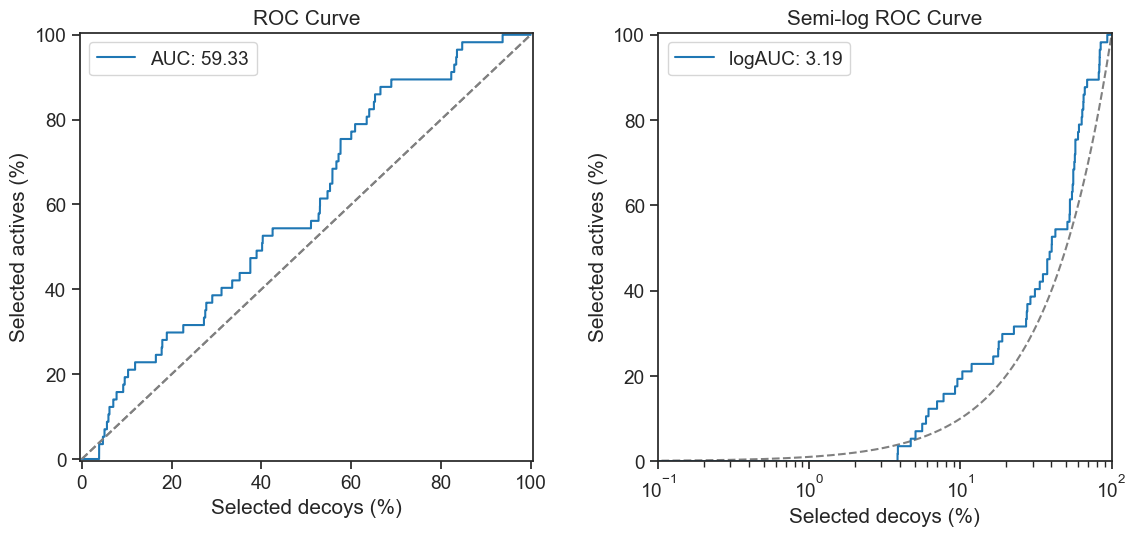

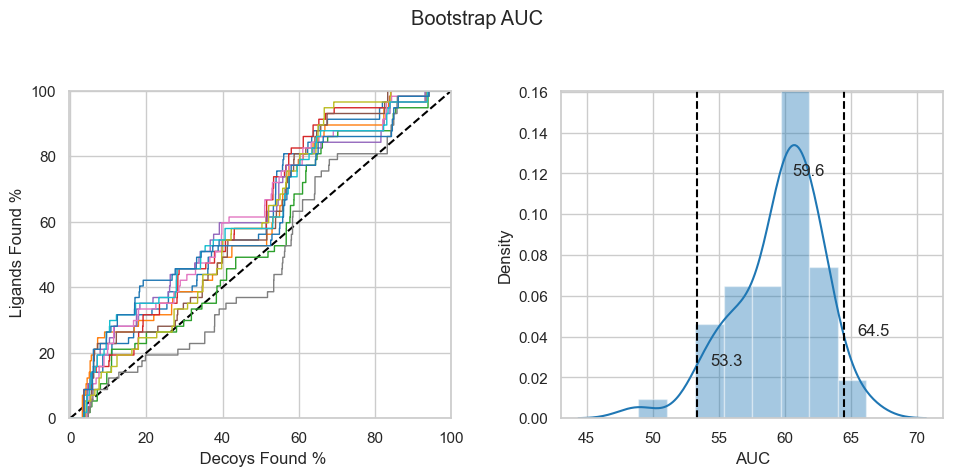

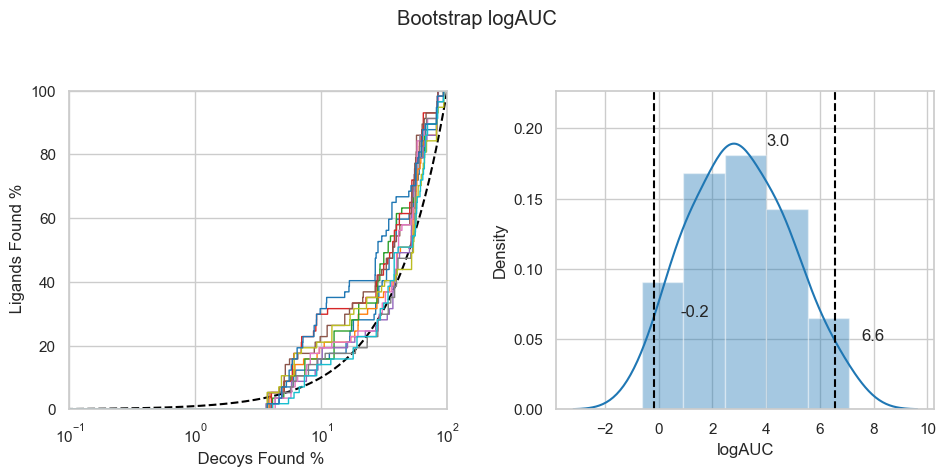

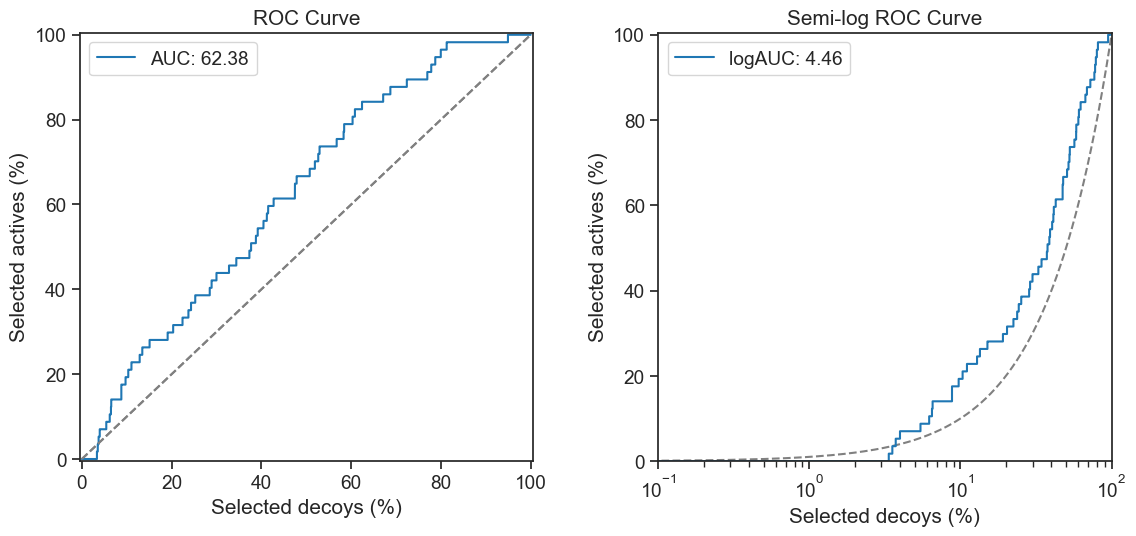

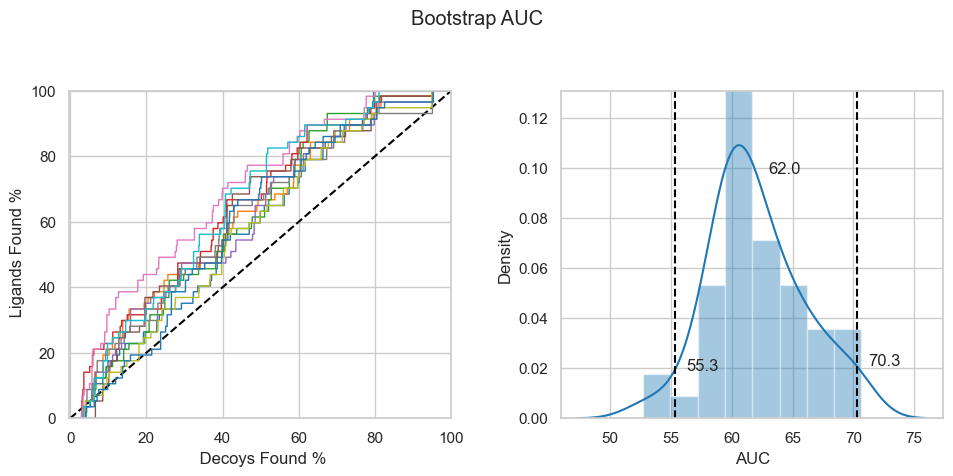

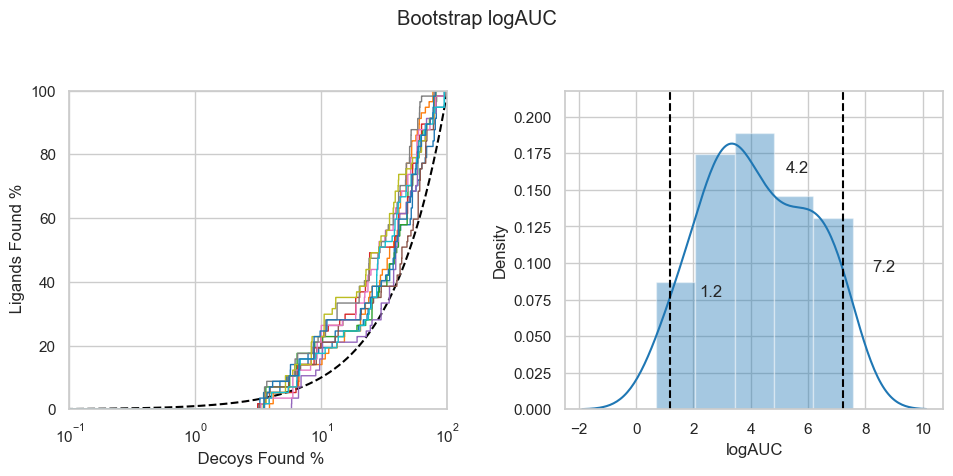

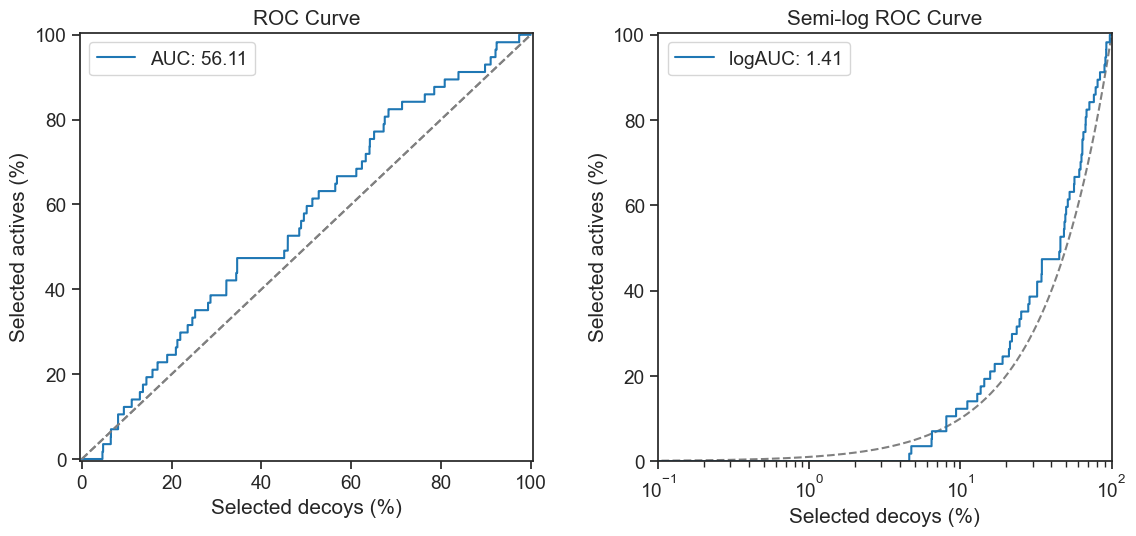

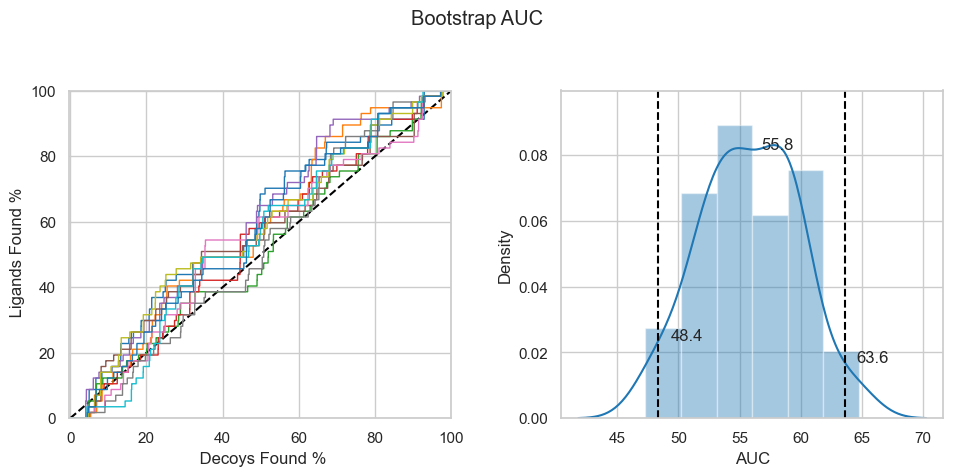

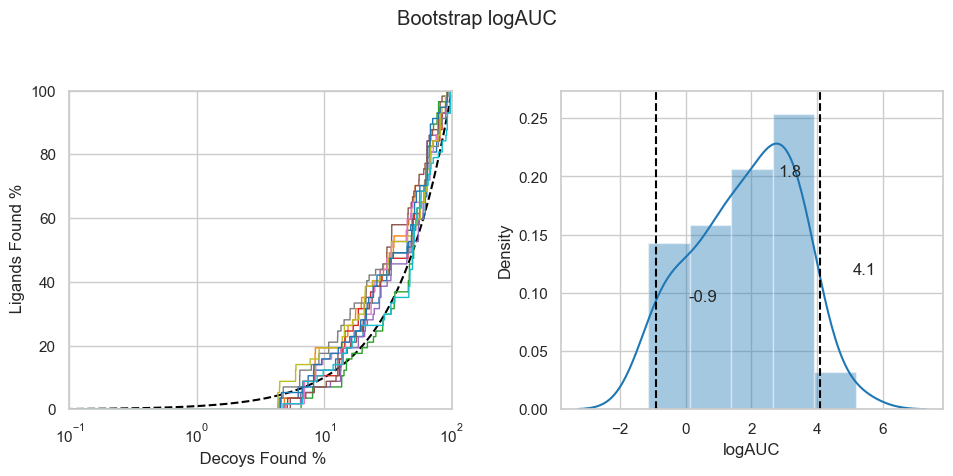

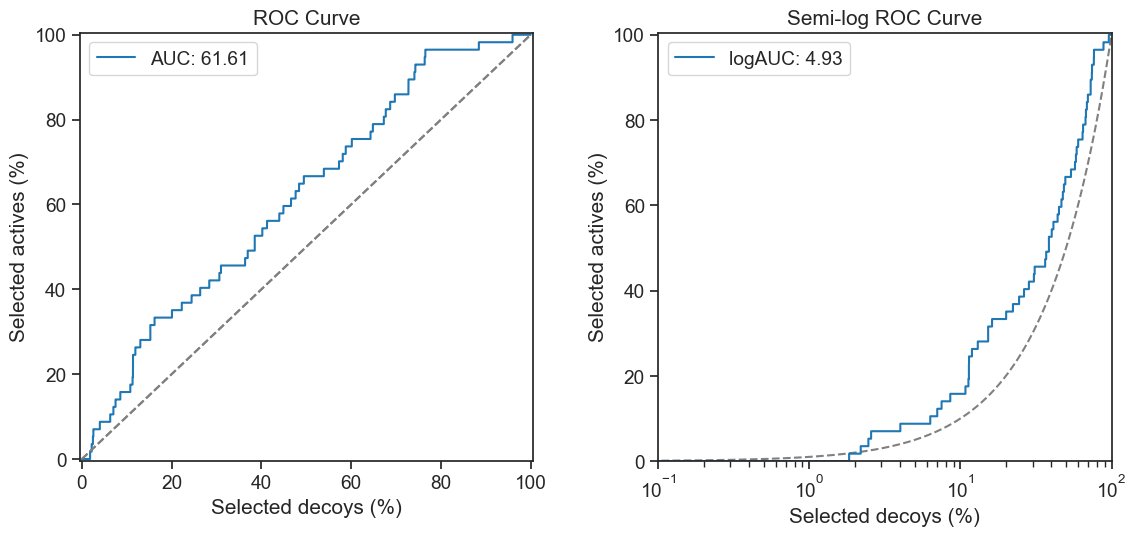

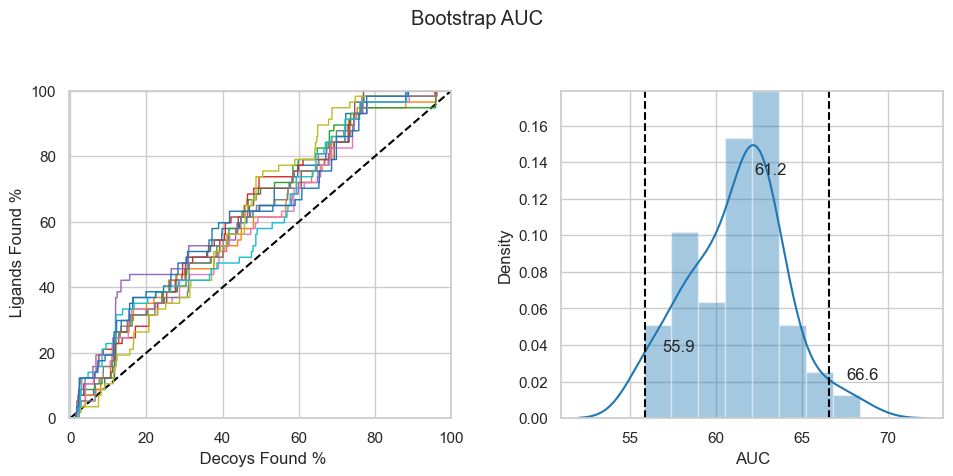

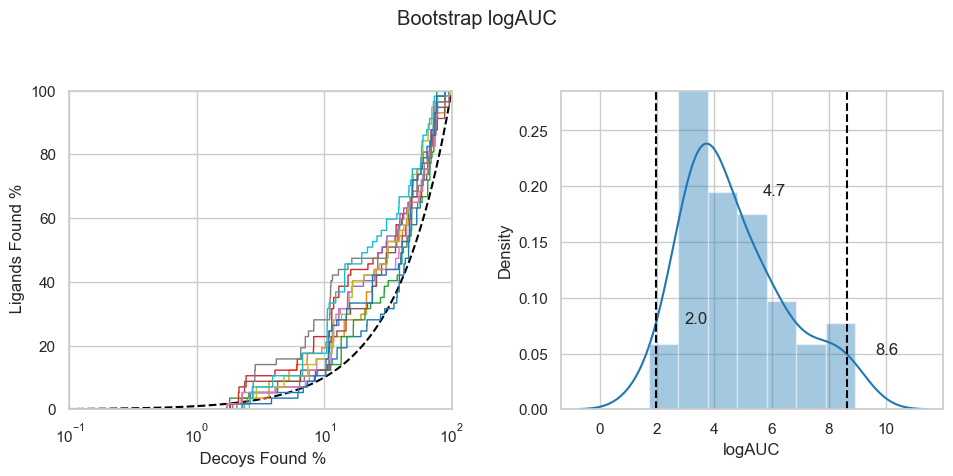

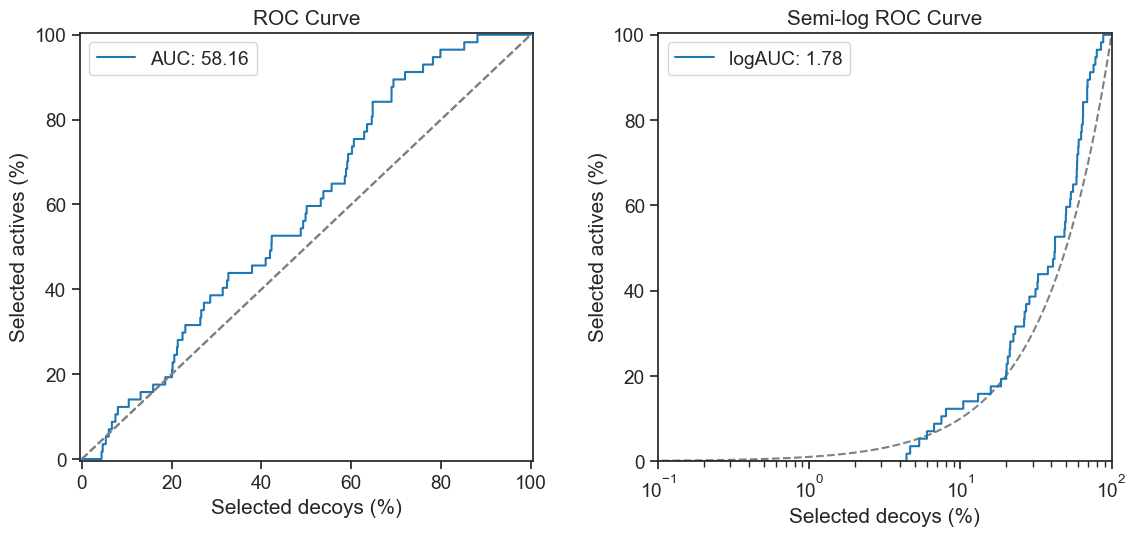

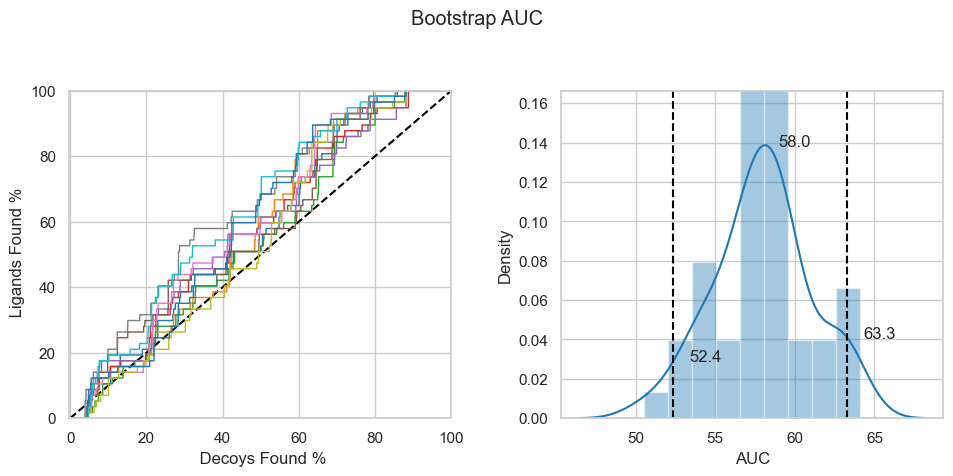

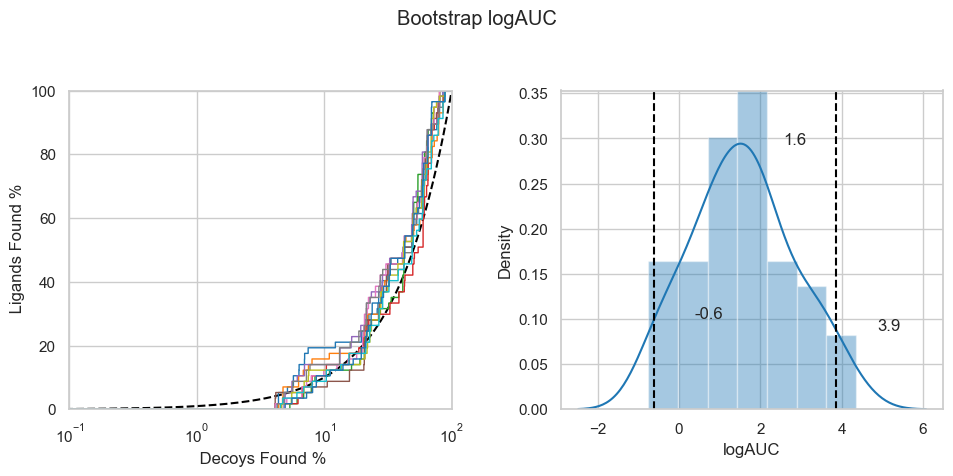

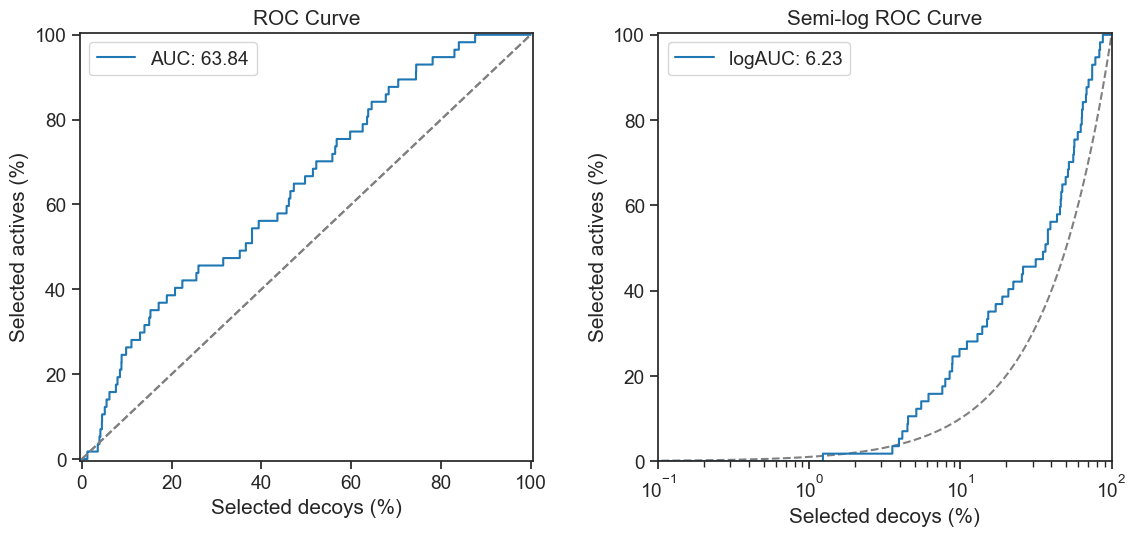

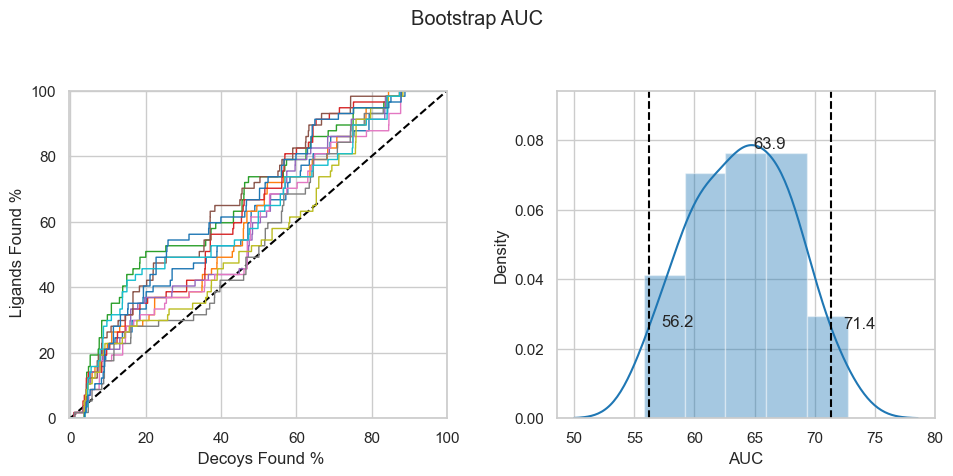

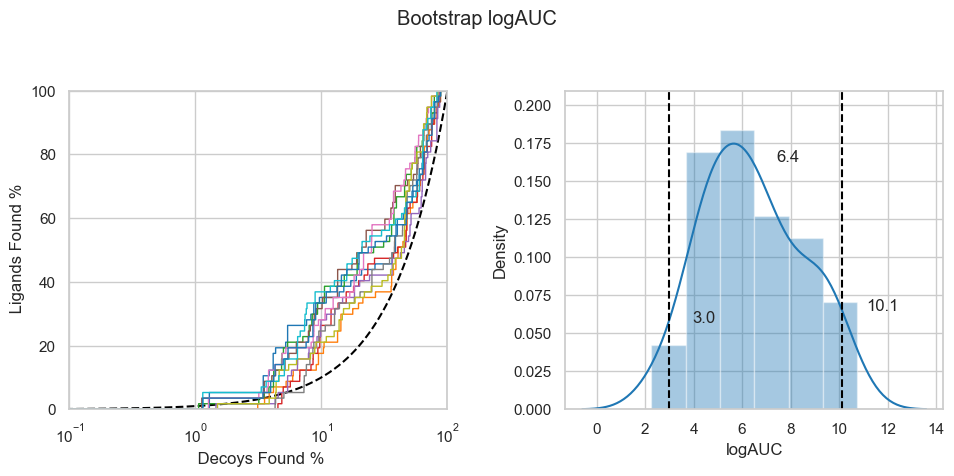

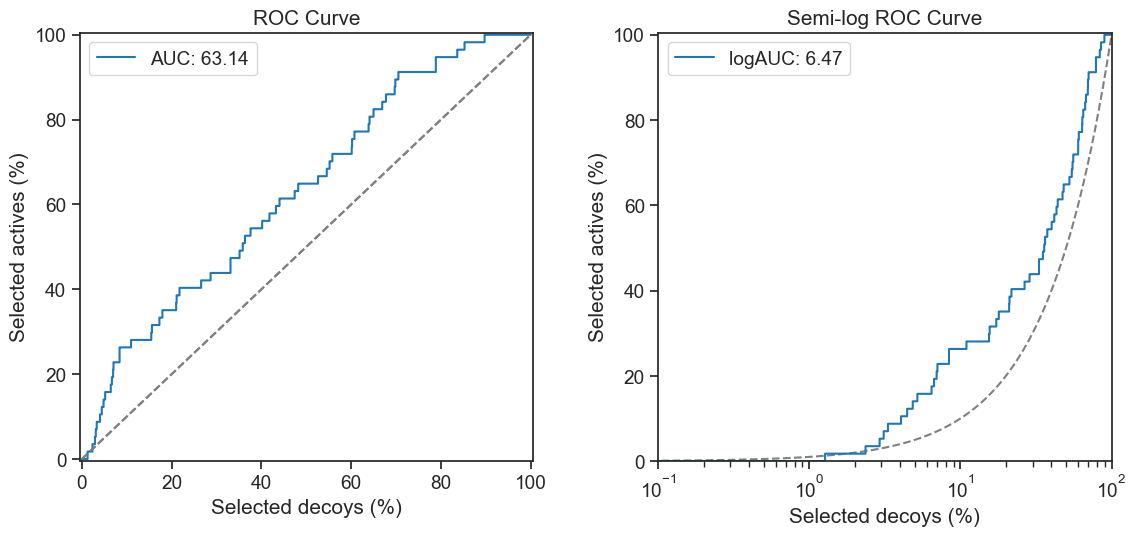

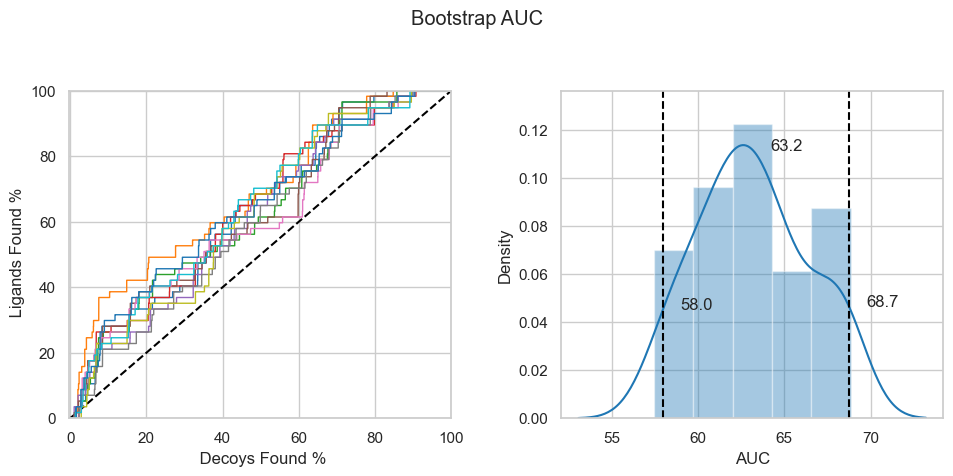

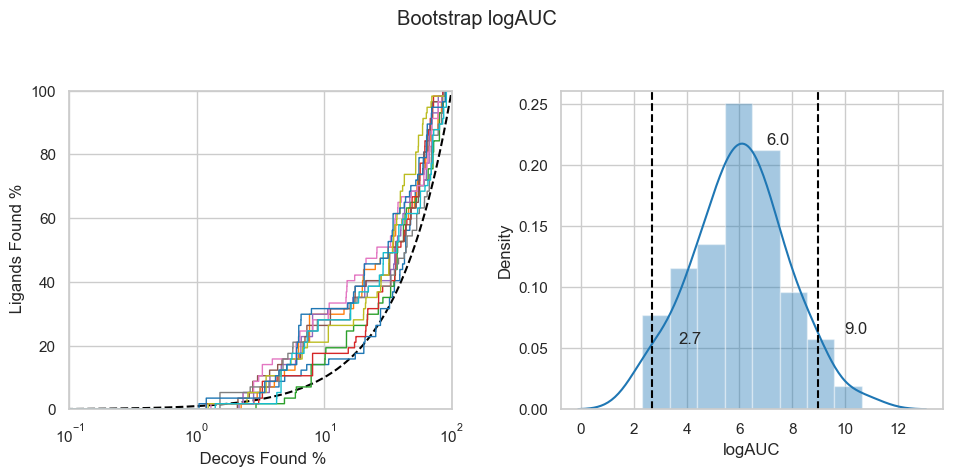

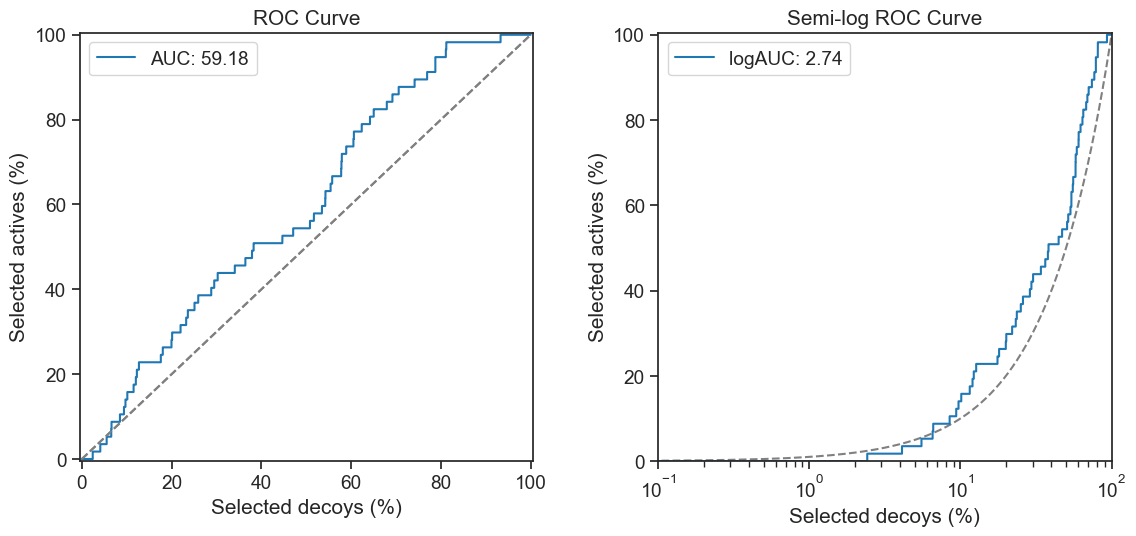

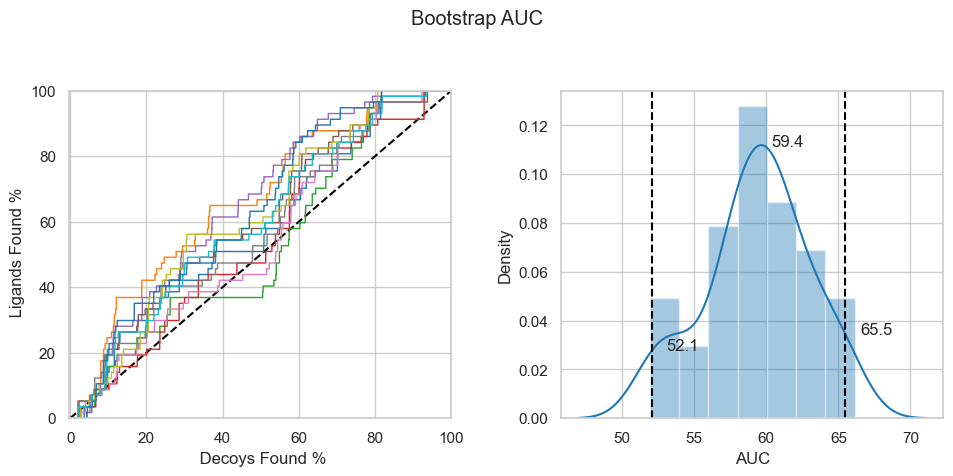

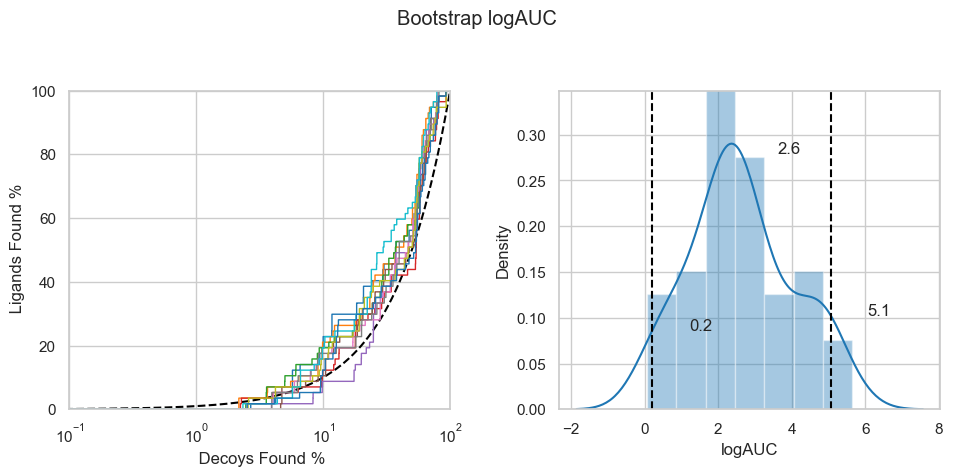

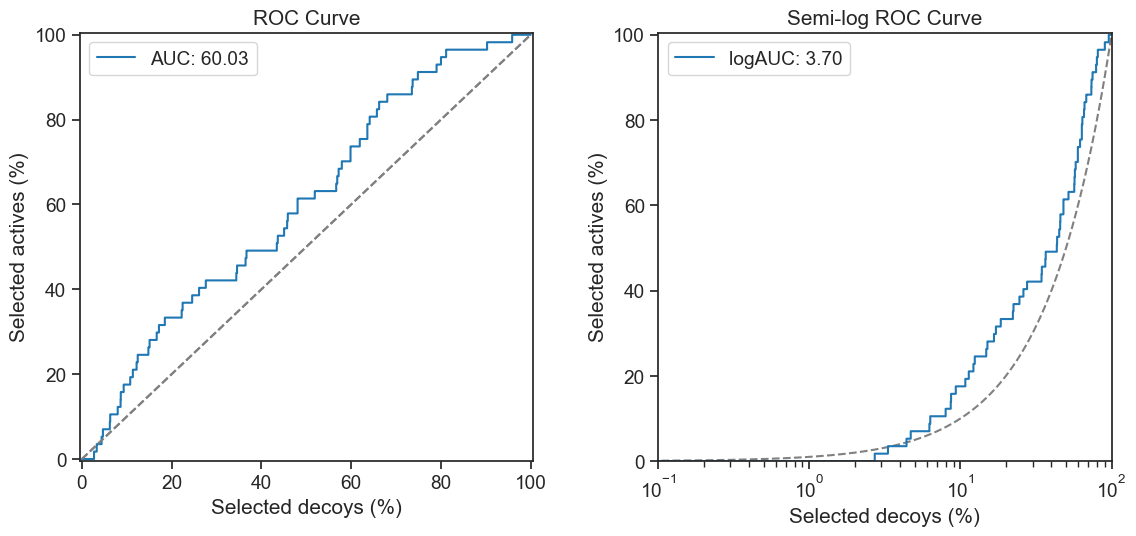

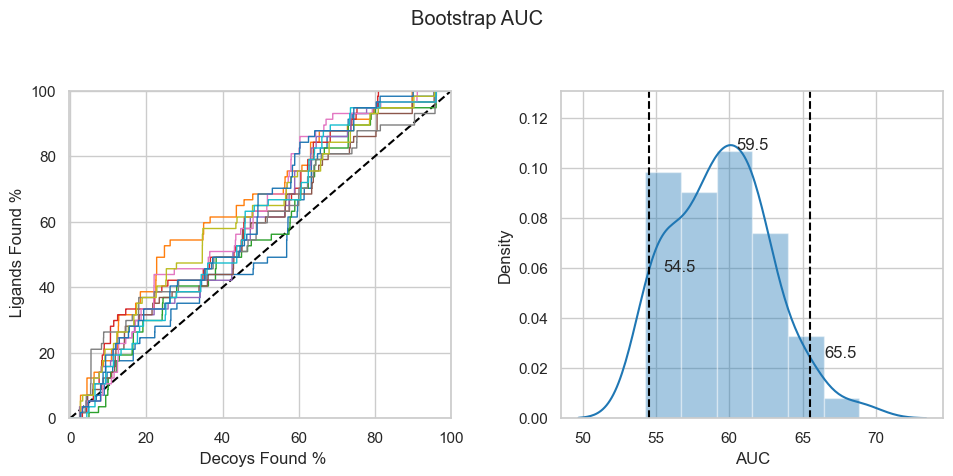

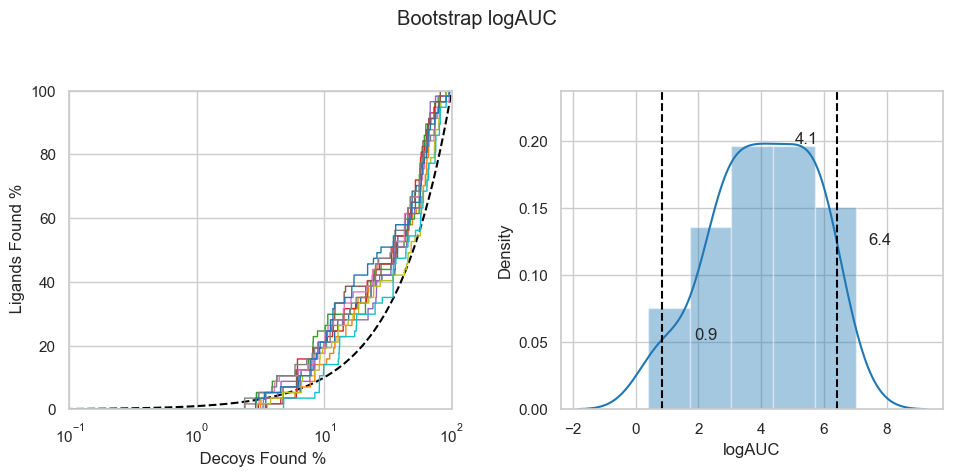

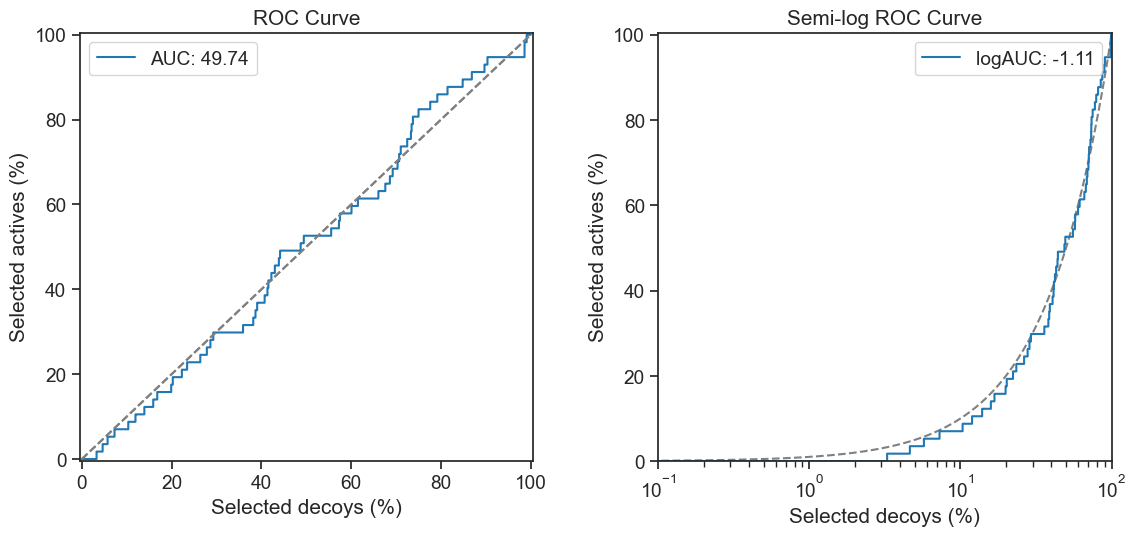

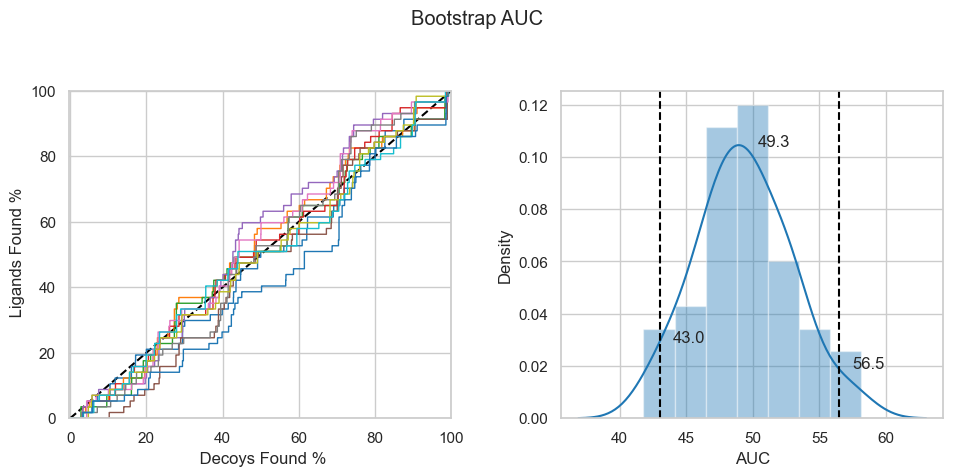

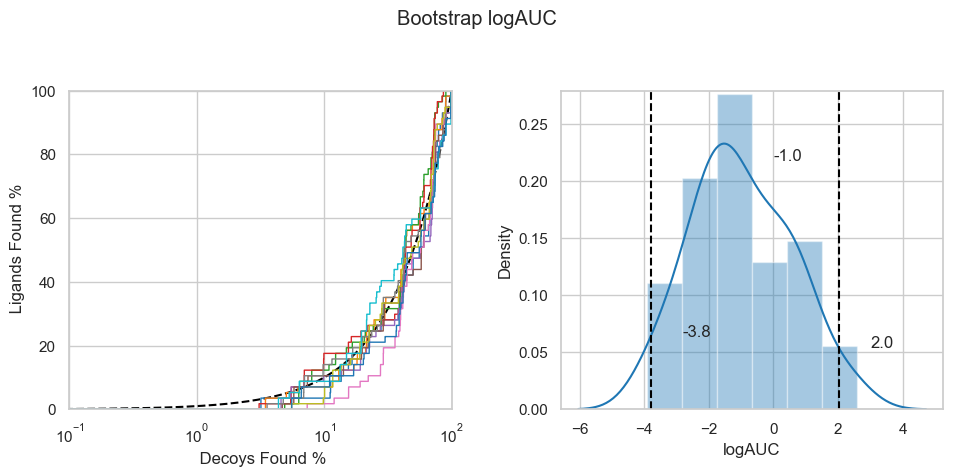

In [4]:
for conformer in G543_2_23Jun:
    print(f"Conformer: {conformer}")
    actives = G543_2_23Jun[conformer]["true_actives"]
    decoys = G543_2_23Jun[conformer]["decoys"]
    plot_roc(actives, decoys, nbins=10000, ligname_col="LigName", score_col="docking_score")
    bootstrap_single_keep_ratio(actives, decoys, metrics="AUC", nbins=10000, ligname_col="LigName", score_col="docking_score", num_bootstrap_replicate=50)
    bootstrap_single_keep_ratio(actives, decoys, metrics="logAUC", nbins=10000, ligname_col="LigName", score_col="docking_score", num_bootstrap_replicate=50)

The classical metric to evaluate the ROC curve is the Area Under the Curve (AUC): the reference values of AUC are 100 for a perfect classification (all true positives selected before any negatives) and 50 for a random classification. For the purpose of virtual screening, instead of optimizing the AUC (represented at the left plot), it is more valuable to optimize the semi-logarithmic ROC curve (right plot). The Area Under the semi-logarithmic ROC curve (logAUC) introduces a bias towards early enrichment (high specificity), which is ideal for virtual screening. This is because, in the semi-log curve, selecting 0-1% of false positives contributes equally to the logAUC as 1-10% (i.e. selecting false positives early decreases the logAUC more than selecting them later compared to standard AUC).


## BEDROC

In [ ]:
for conformer in G543_12Jun.keys():
    print(f"Conformer: {conformer}")
    b_actives = G543_12Jun[conformer]["true_actives"].copy()
    b_actives['active'] = 1
    b_decoys = G543_12Jun[conformer]["decoys"].copy()
    b_decoys['active'] = 0

    b_all = pd.concat([b_actives, b_decoys], ignore_index=True)
    b_all = b_all.sort_values("docking_score")

    scores = list(
        zip(
            b_all["active"].tolist(),
            b_all["docking_score"].tolist()
        )
    )

    bedroc = CalcBEDROC(scores, col=0, alpha=80.0)
    print(f"BEDROC: {bedroc}")

Conformer: 4h2i_c_1
BEDROC: 0.003423560456084526
Conformer: 4h2i_c_2
BEDROC: 0.009469272584132618
Conformer: 4h2i_c_3
BEDROC: 0.0012188219162982514
Conformer: 4h2i_c_4
BEDROC: 0.011757042248609616
Conformer: 4h2i_crys
BEDROC: 0.0020418283330558918
Conformer: 6tve_c_1
BEDROC: 0.00987955110463655
Conformer: 6tve_c_2
BEDROC: 0.015109865455845813
Conformer: 6tve_c_3
BEDROC: 0.0012146451572422389
Conformer: 6tve_c_4
BEDROC: 0.0031815450754627424
Conformer: 6tve_crys
BEDROC: 0.0008009169035074504


## Enrichment Factor

In the next cells we verify that the actives and decoys actually match in molecular weight using RDKit. You will need to provide the .smi files with the ligand IDs and SMILES codes.

In [14]:
def enrichment_factor(df, fraction):
    df = df.sort_values("docking_score")

    n_total = len(df)
    n_actives = df["active"].sum()

    n_top = max(1, int(np.ceil(n_total * fraction)))

    actives_in_top = df.head(n_top)["active"].sum()

    return (
        (actives_in_top / n_top)
        /
        (n_actives / n_total)
    )

In [ ]:
for conformer in G543_12Jun.keys():
    print(f"Conformer: {conformer}")
    b_actives = G543_12Jun[conformer]["true_actives"].copy()
    b_actives['active'] = 1
    b_decoys = G543_12Jun[conformer]["decoys"].copy()
    b_decoys['active'] = 0

    b_all = pd.concat([b_actives, b_decoys], ignore_index=True)
    b_all = b_all.sort_values("docking_score")

    for fraction in [0.001, 0.005, 0.01, 0.02, 0.05]:
        ef = enrichment_factor(b_all, fraction)
        print(f"Enrichment factor at {fraction*100:.2f}%: {ef:.2f}")

Conformer: 4h2i_c_1
Enrichment factor at 0.10%: 0.00
Enrichment factor at 0.50%: 0.00
Enrichment factor at 1.00%: 0.00
Enrichment factor at 2.00%: 0.00
Enrichment factor at 5.00%: 0.35
Conformer: 4h2i_c_2
Enrichment factor at 0.10%: 0.00
Enrichment factor at 0.50%: 0.00
Enrichment factor at 1.00%: 0.00
Enrichment factor at 2.00%: 0.00
Enrichment factor at 5.00%: 1.75
Conformer: 4h2i_c_3
Enrichment factor at 0.10%: 0.00
Enrichment factor at 0.50%: 0.00
Enrichment factor at 1.00%: 0.00
Enrichment factor at 2.00%: 0.00
Enrichment factor at 5.00%: 0.35
Conformer: 4h2i_c_4
Enrichment factor at 0.10%: 0.00
Enrichment factor at 0.50%: 0.00
Enrichment factor at 1.00%: 0.00
Enrichment factor at 2.00%: 0.00
Enrichment factor at 5.00%: 1.05
Conformer: 4h2i_crys
Enrichment factor at 0.10%: 0.00
Enrichment factor at 0.50%: 0.00
Enrichment factor at 1.00%: 0.00
Enrichment factor at 2.00%: 0.00
Enrichment factor at 5.00%: 0.35
Conformer: 6tve_c_1
Enrichment factor at 0.10%: 0.00
Enrichment factor at 

# True actives vs true inactives

Conformer: 4h2i_c_1
lig_list:  57,   decoy_list:84
lig_scores:57, decoy_scores:84


100%|███████████████████████████████████████████████████████████████| 50/50 [00:01<00:00, 25.38it/s]
/var/folders/5z/10m2qplj4qj3rl5cq75k57600000gp/T/ipykernel_21639/3377116991.py:184: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  dist_plot = sns.distplot(list_logauc, ax=ax2, kde=True)#, bins=15 )


lig_list:  57,   decoy_list:84
lig_scores:57, decoy_scores:84


100%|███████████████████████████████████████████████████████████████| 50/50 [00:02<00:00, 24.94it/s]
/var/folders/5z/10m2qplj4qj3rl5cq75k57600000gp/T/ipykernel_21639/3377116991.py:184: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  dist_plot = sns.distplot(list_logauc, ax=ax2, kde=True)#, bins=15 )


Conformer: 4h2i_c_2
lig_list:  57,   decoy_list:84
lig_scores:57, decoy_scores:84


...

100%|███████████████████████████████████████████████████████████████| 50/50 [00:02<00:00, 20.60it/s]
/var/folders/5z/10m2qplj4qj3rl5cq75k57600000gp/T/ipykernel_21639/3377116991.py:184: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  dist_plot = sns.distplot(list_logauc, ax=ax2, kde=True)#, bins=15 )


Conformer: 6tve_crys
lig_list:  57,   decoy_list:84
lig_scores:57, decoy_scores:84


100%|███████████████████████████████████████████████████████████████| 50/50 [00:02<00:00, 21.44it/s]
/var/folders/5z/10m2qplj4qj3rl5cq75k57600000gp/T/ipykernel_21639/3377116991.py:184: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  dist_plot = sns.distplot(list_logauc, ax=ax2, kde=True)#, bins=15 )


lig_list:  57,   decoy_list:84
lig_scores:57, decoy_scores:84


100%|███████████████████████████████████████████████████████████████| 50/50 [00:02<00:00, 19.99it/s]
/var/folders/5z/10m2qplj4qj3rl5cq75k57600000gp/T/ipykernel_21639/3377116991.py:184: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  dist_plot = sns.distplot(list_logauc, ax=ax2, kde=True)#, bins=15 )


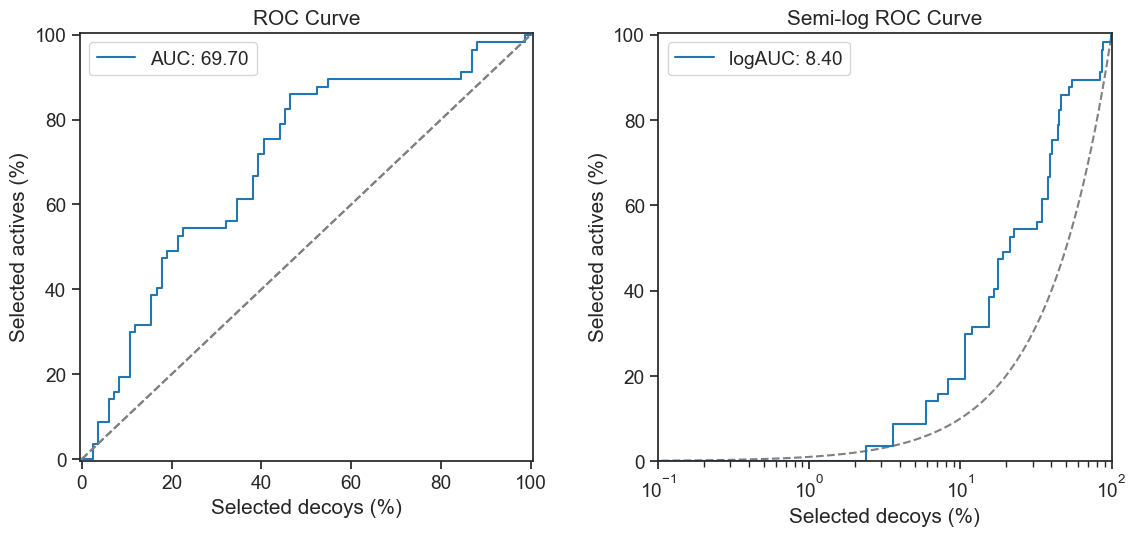

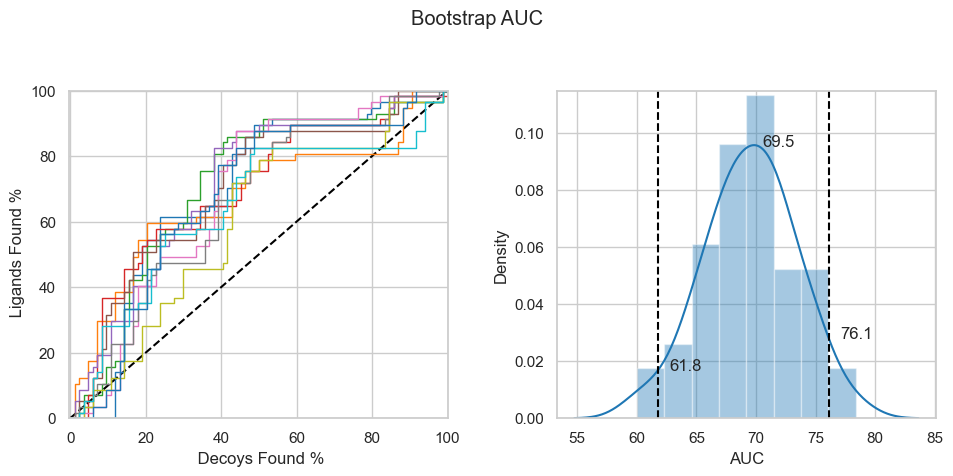

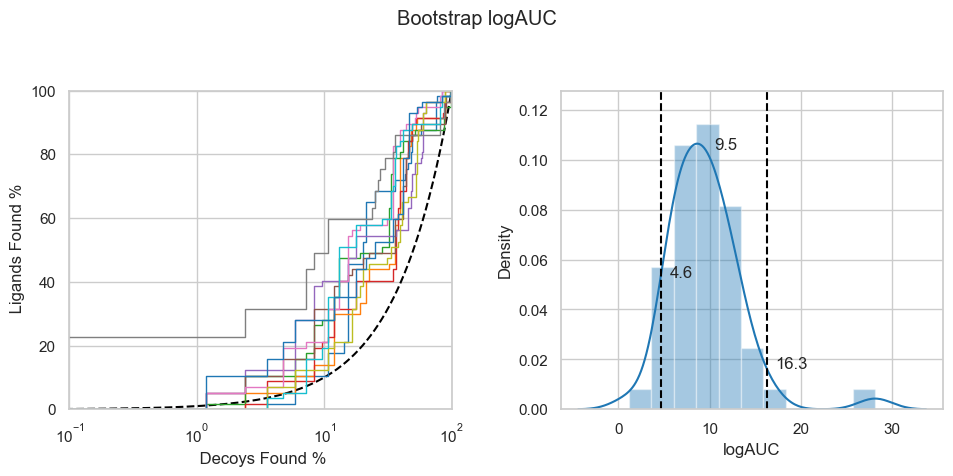

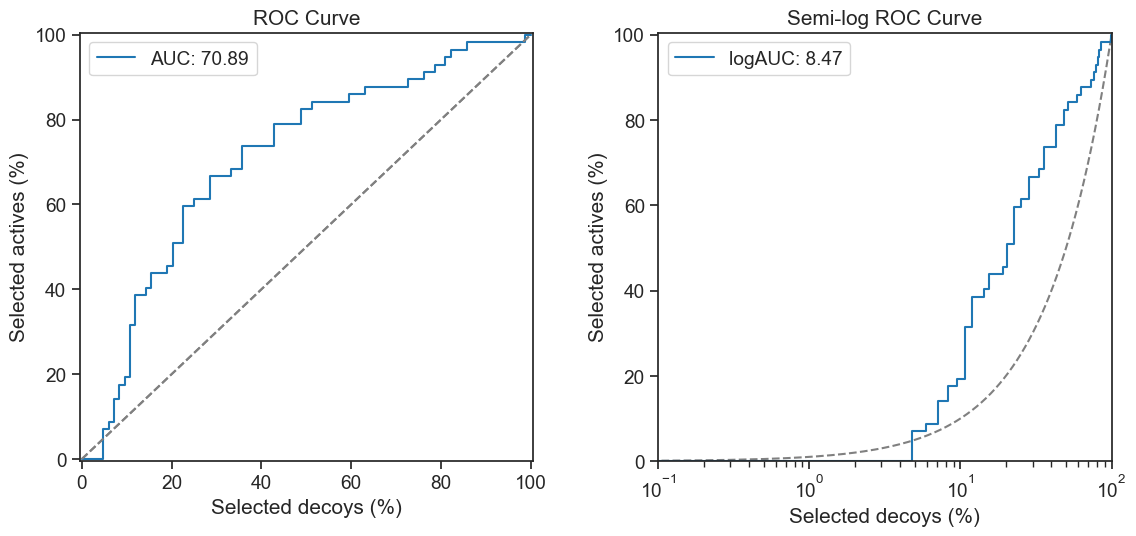

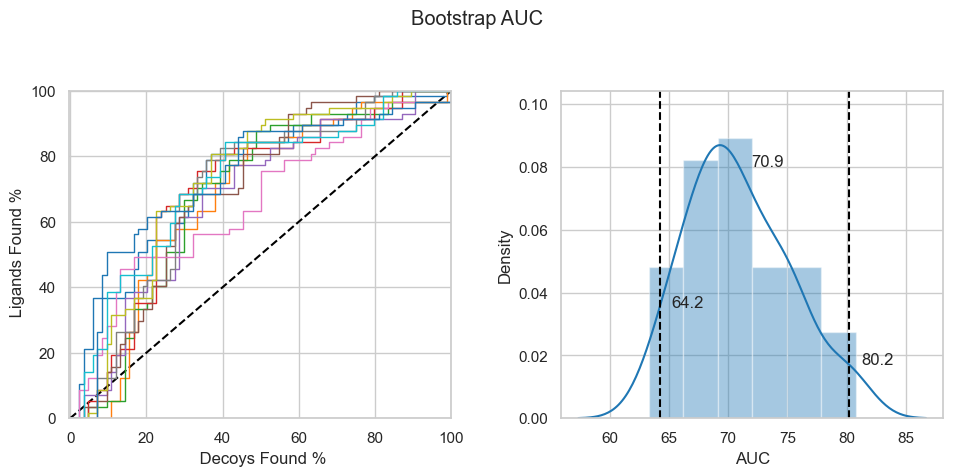

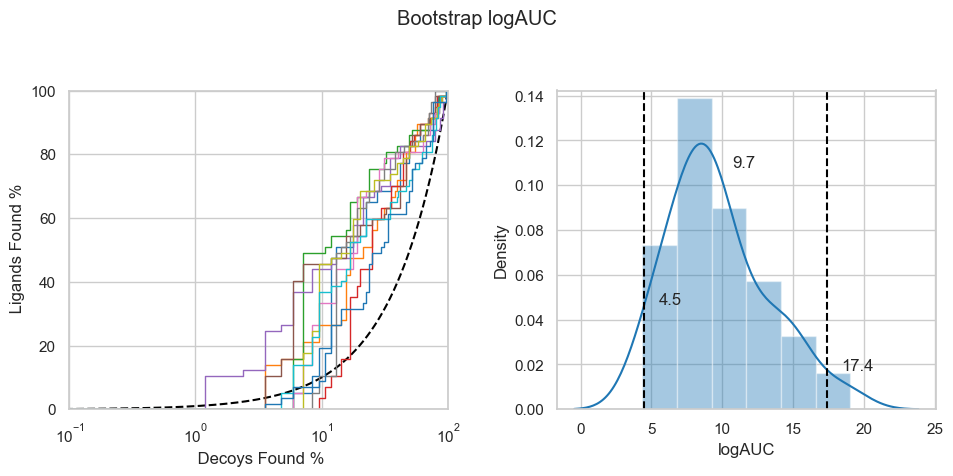

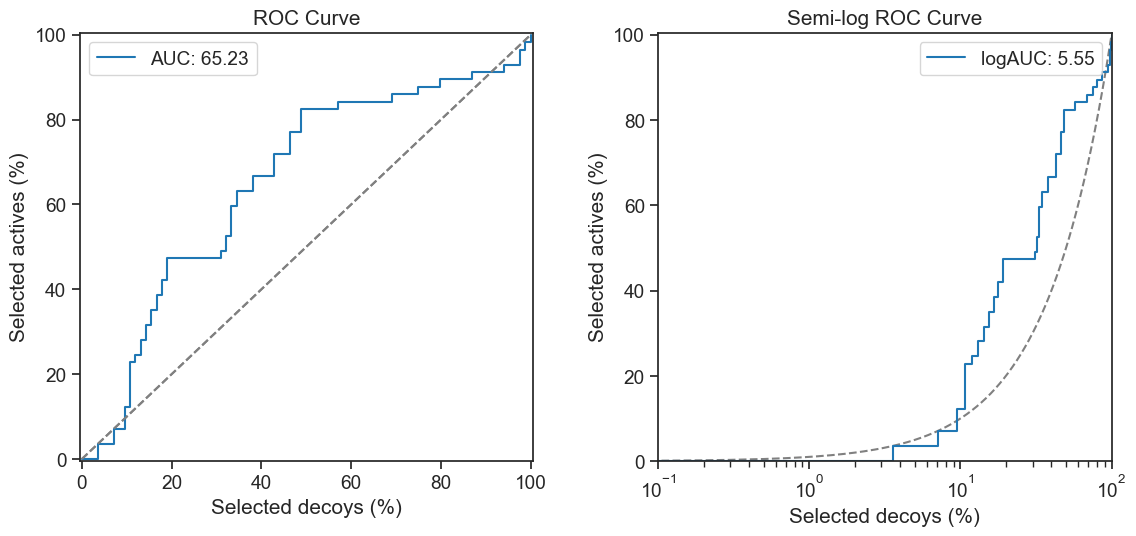

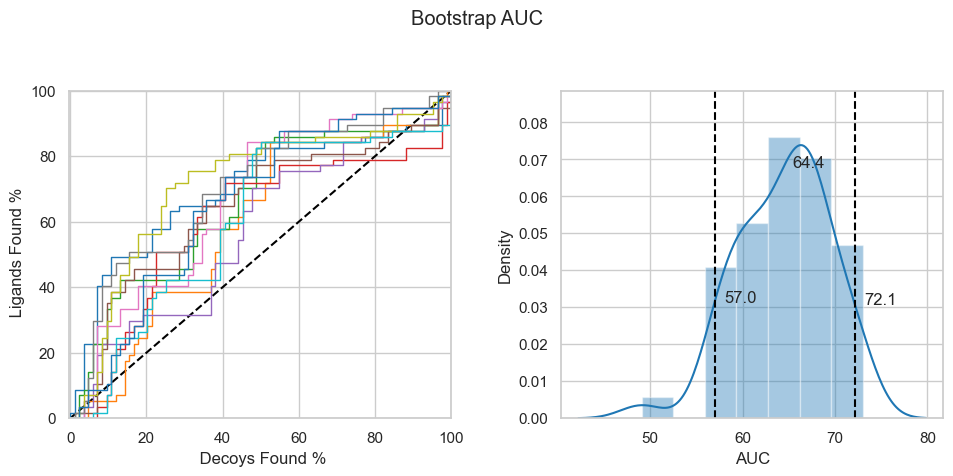

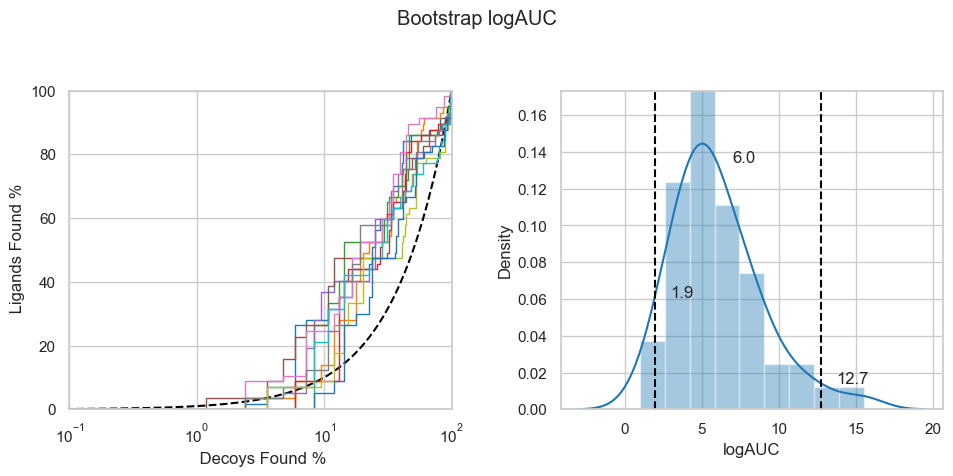

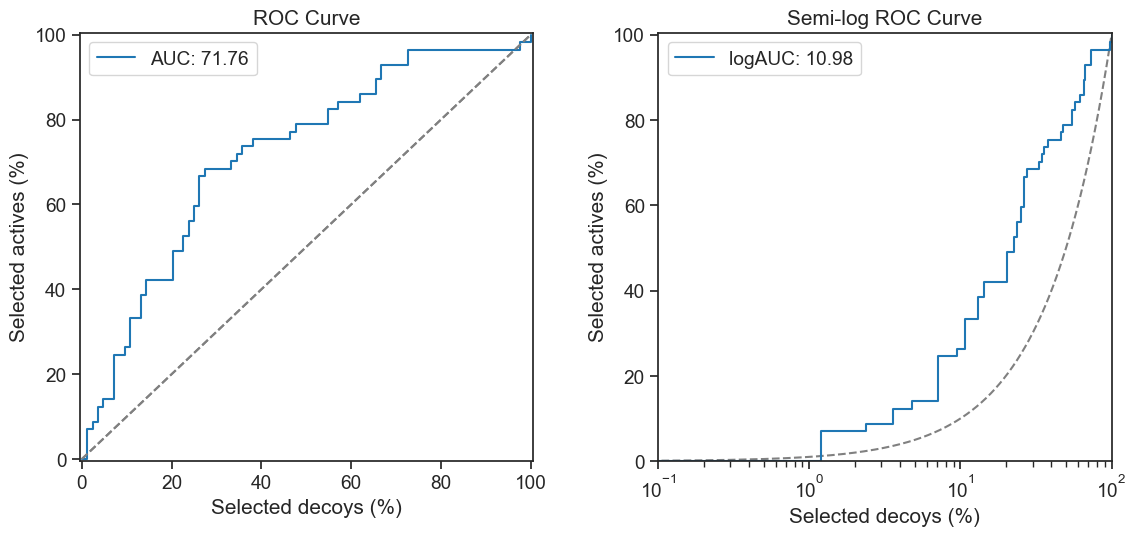

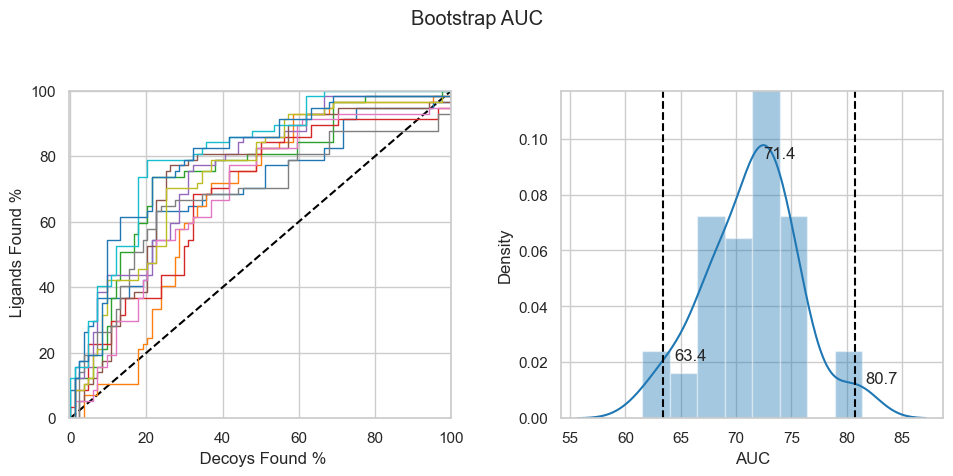

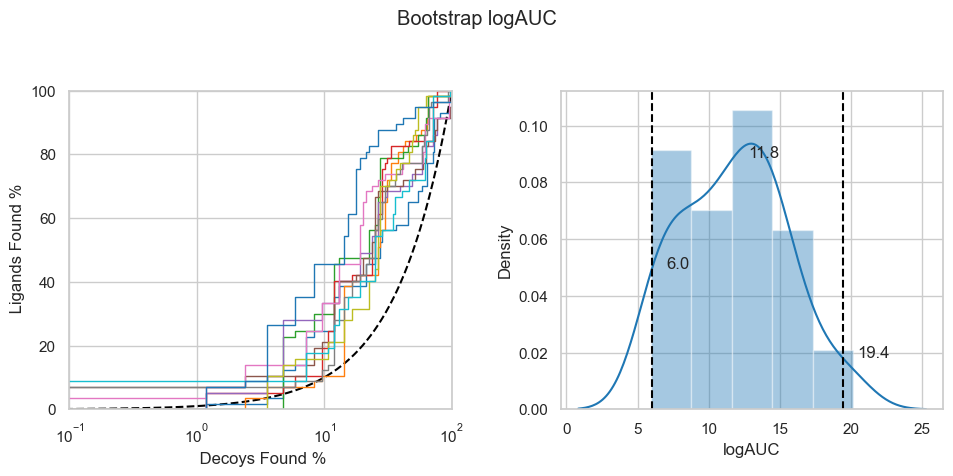

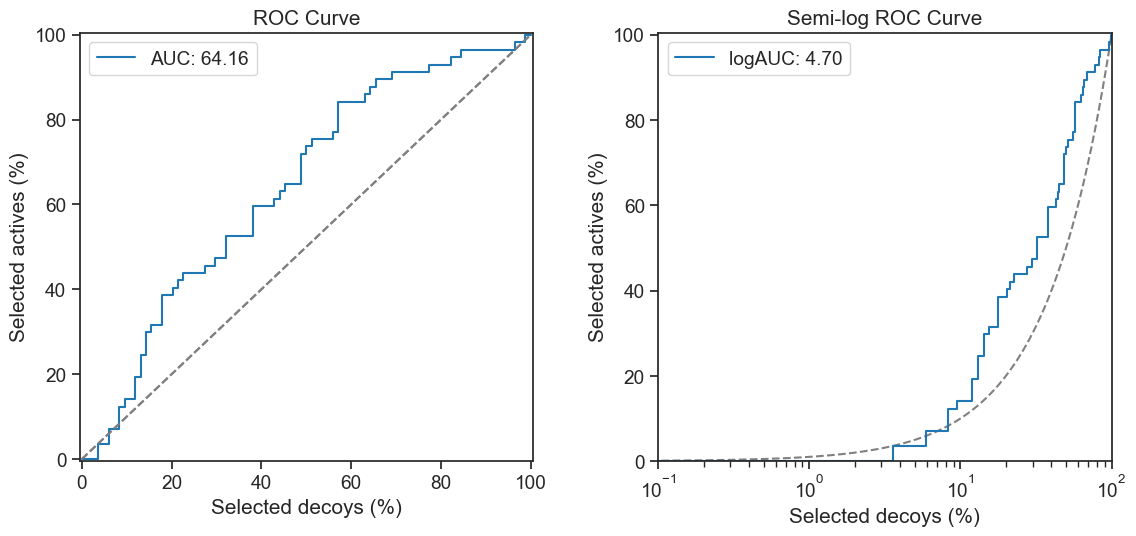

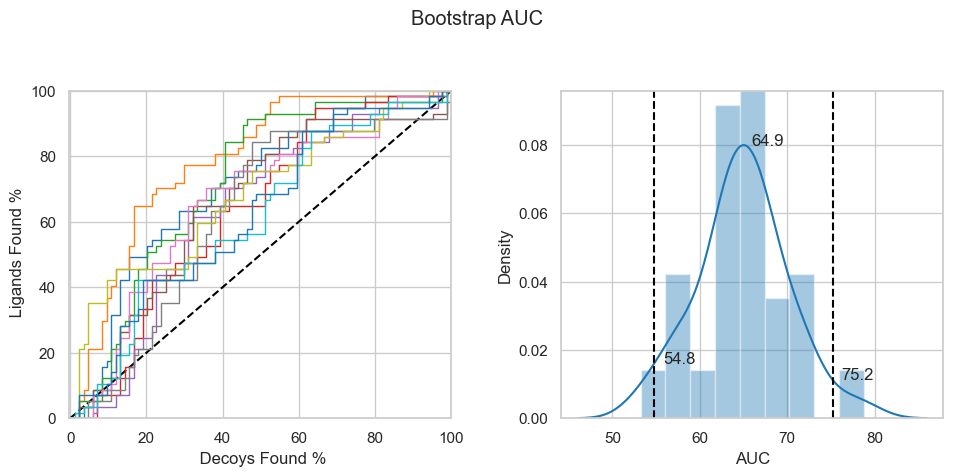

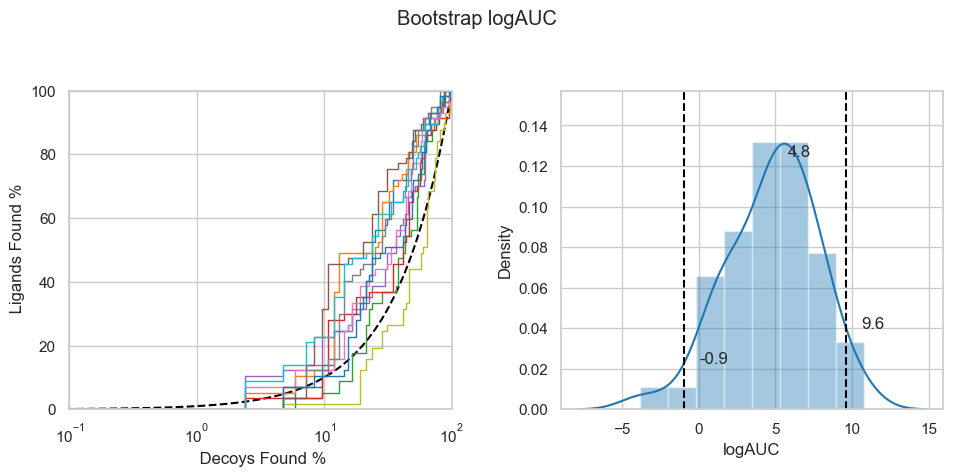

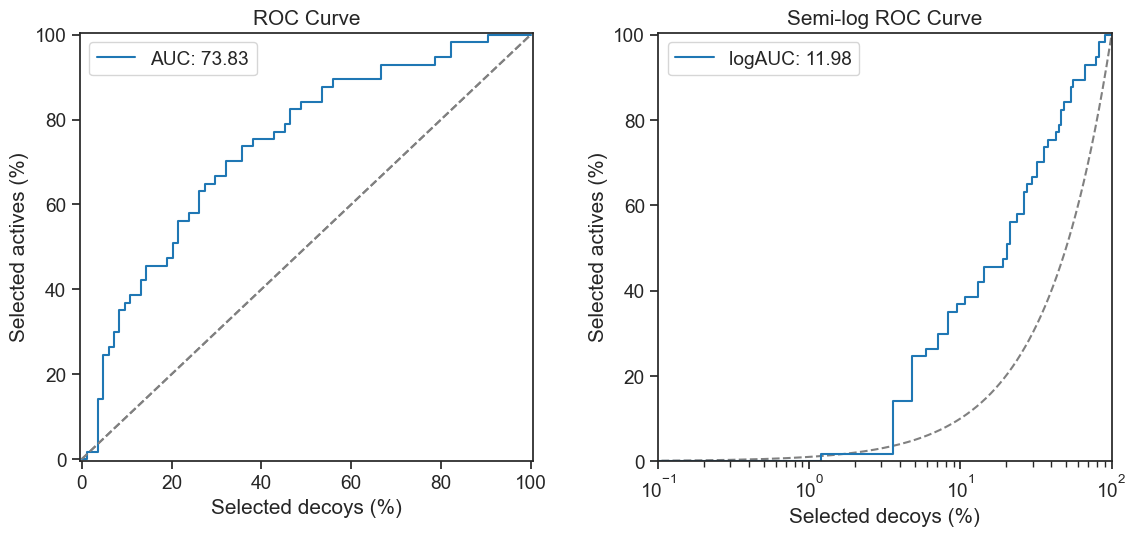

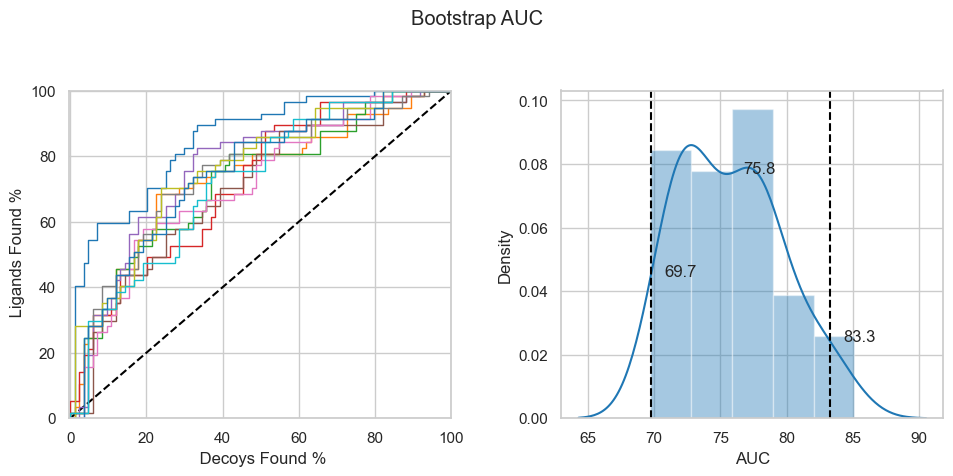

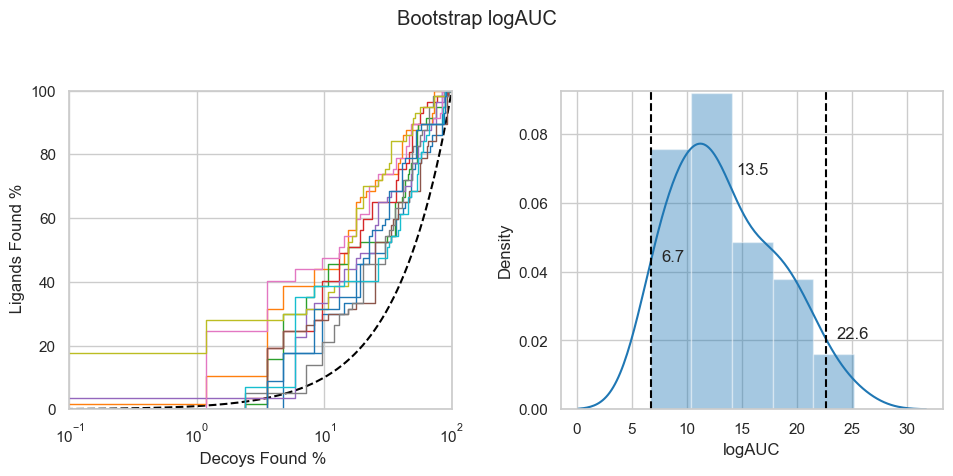

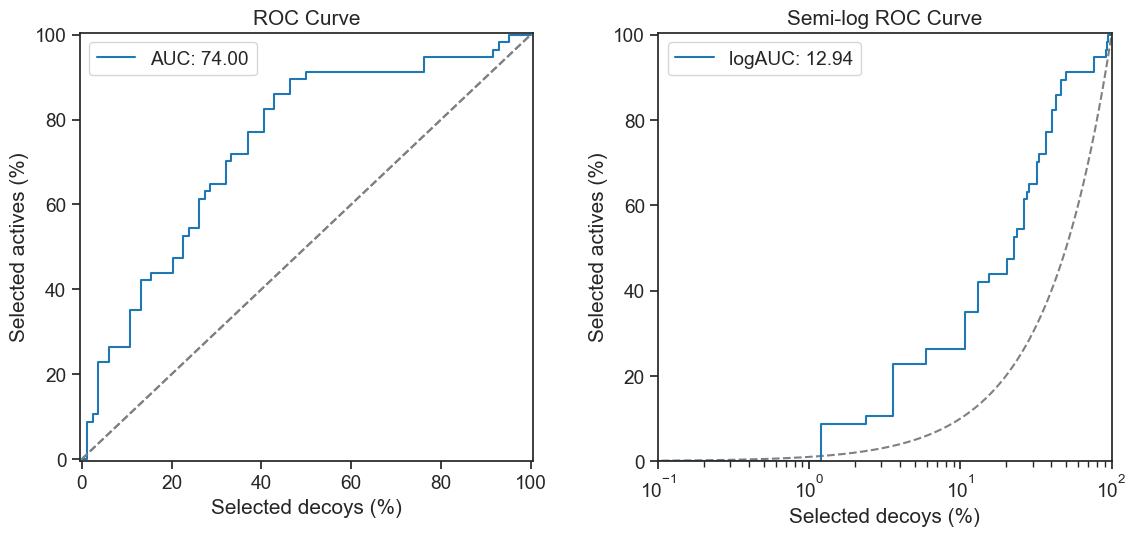

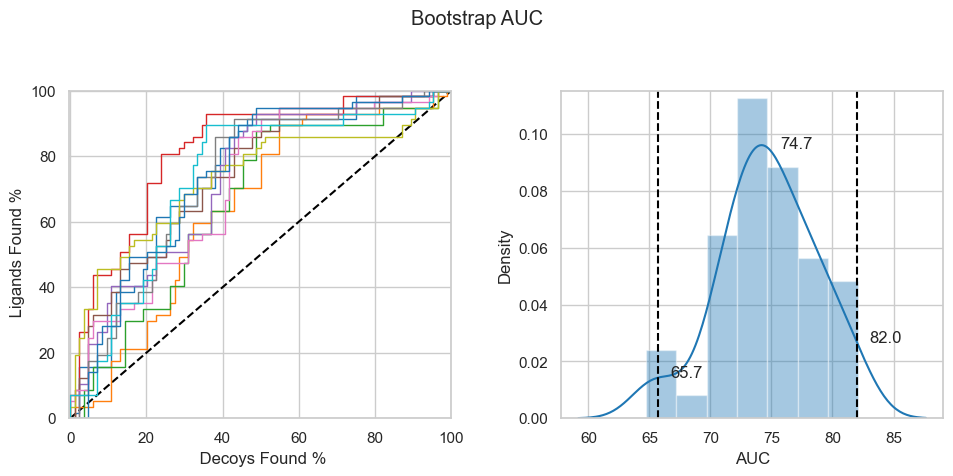

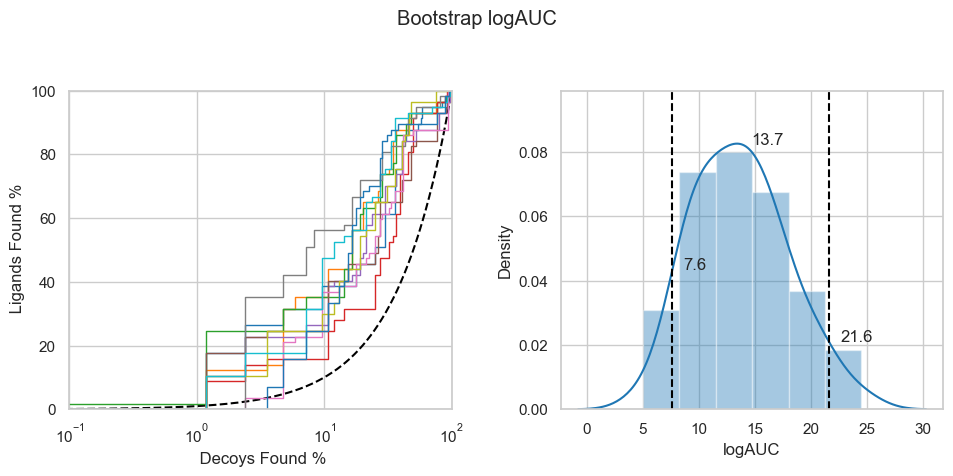

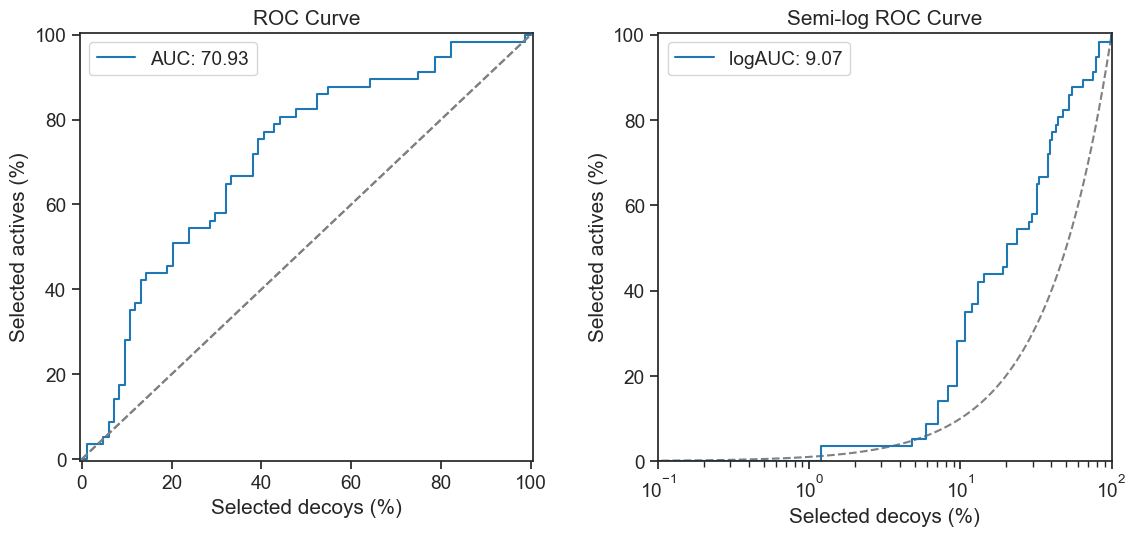

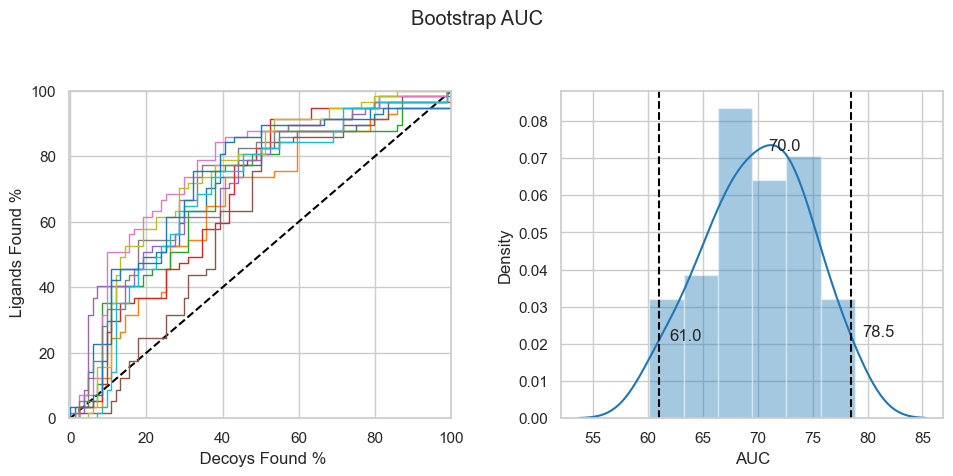

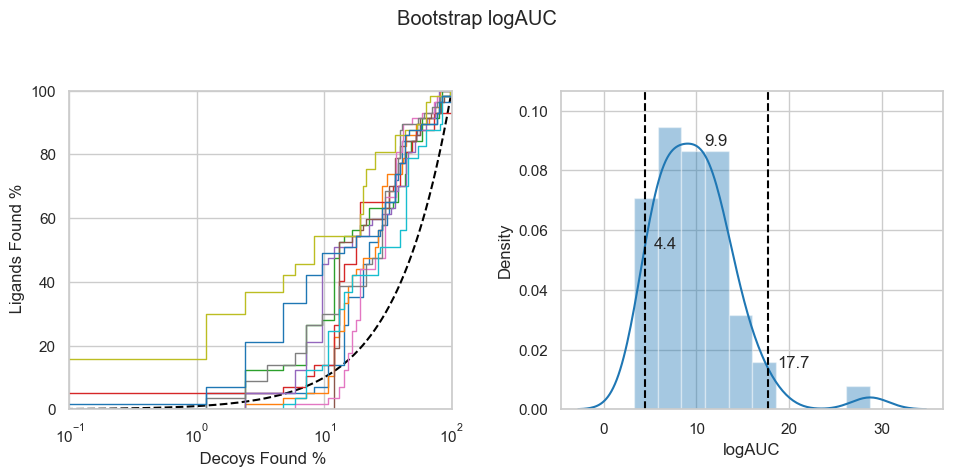

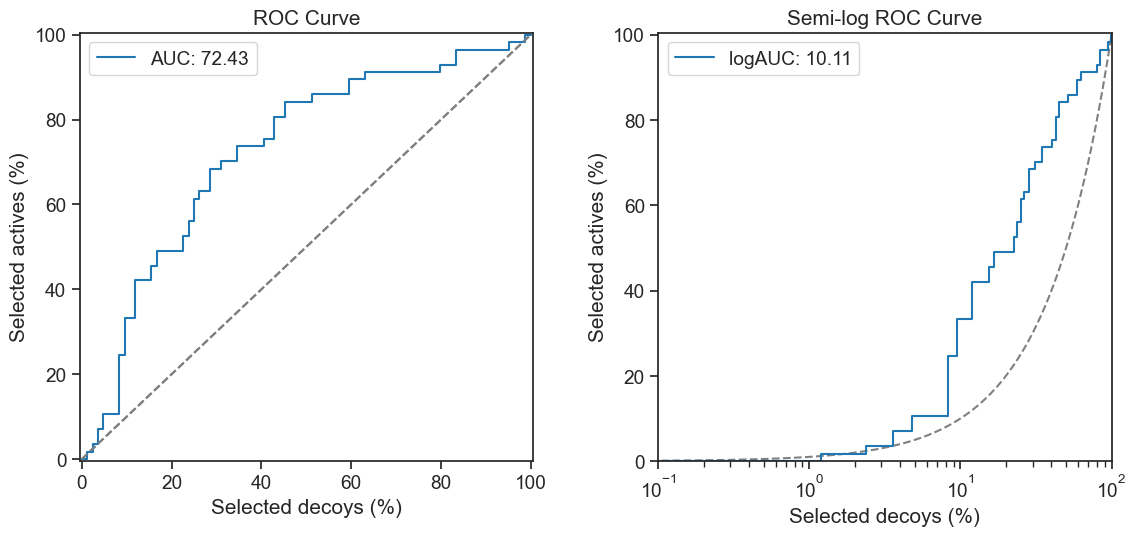

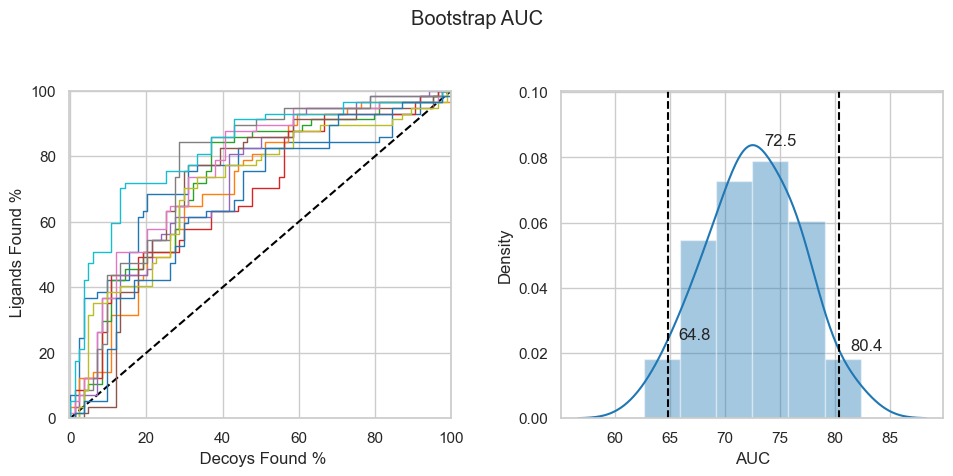

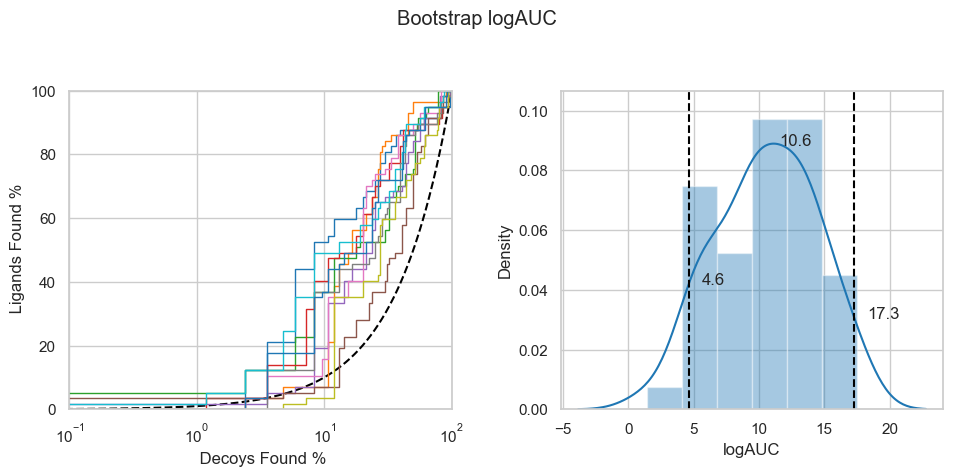

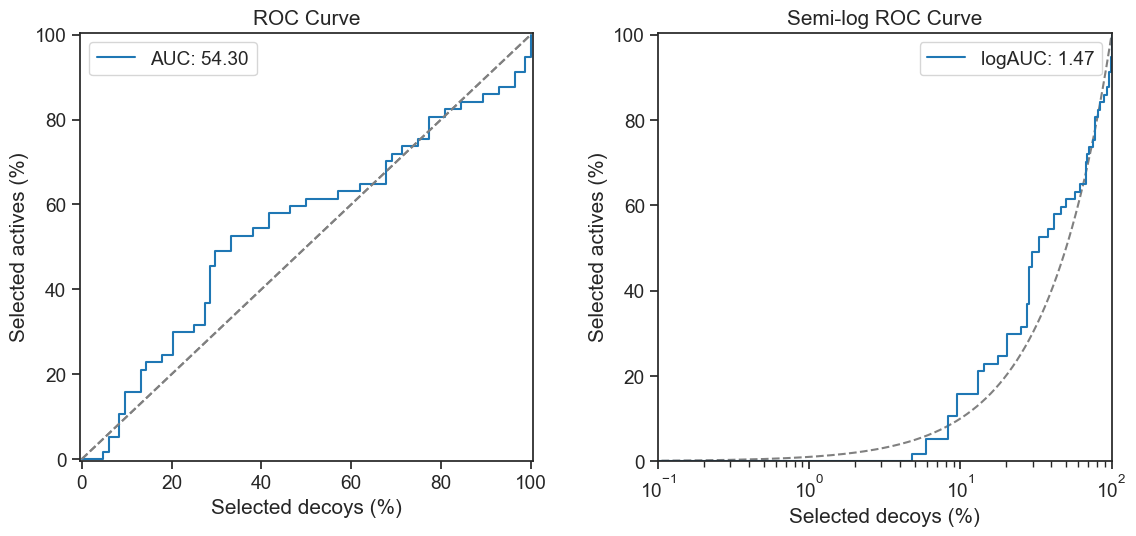

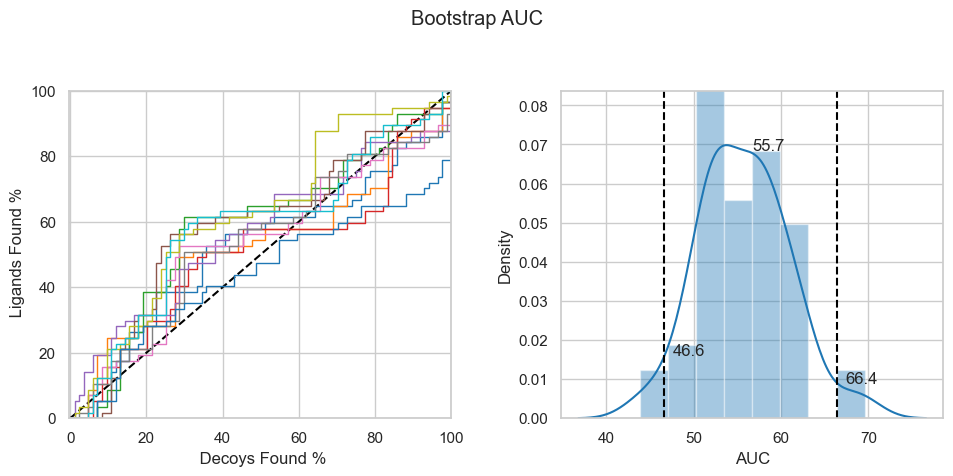

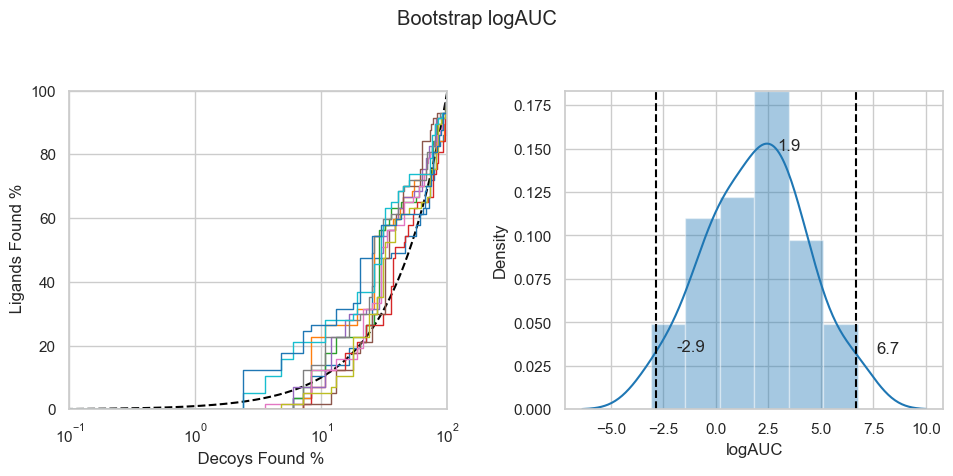

In [5]:
for conformer in G543_2_23Jun.keys():
    print(f"Conformer: {conformer}")
    true_actives = G543_2_23Jun[conformer]["true_actives"]
    true_inactives = G543_2_23Jun[conformer]["true_inactives"]
    plot_roc(true_actives, true_inactives, nbins=10000, ligname_col="LigName", score_col="docking_score")
    bootstrap_single_keep_ratio(true_actives, true_inactives, metrics="AUC", nbins=10000, ligname_col="LigName", score_col="docking_score", num_bootstrap_replicate=50)
    bootstrap_single_keep_ratio(true_actives, true_inactives, metrics="logAUC", nbins=10000, ligname_col="LigName", score_col="docking_score", num_bootstrap_replicate=50)